In [ ]:
from google.colab import drive
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import warnings
warnings.filterwarnings('ignore')

# Kết nối Google Drive
drive.mount('/content/drive')
# ĐƯỜNG DẪN ĐẾN THƯ MỤC DATATHON
path = '/content/drive/MyDrive/datathon/'
files = {
    'products': 'products.csv',
    'customers': 'customers.csv',
    'promotions': 'promotions.csv',
    'geography': 'geography.csv',
    'orders': 'orders.csv',
    'order_items': 'order_items.csv',
    'payments': 'payments.csv',
    'shipments': 'shipments.csv',
    'returns': 'returns.csv',
    'reviews': 'reviews.csv',
    'sales': 'sales.csv',
    'inventory': 'inventory.csv',
    'web_traffic': 'web_traffic.csv',
    'sample_submission': 'sample_submission.csv'
}
data = {}

print("="*60)
print("ĐANG ĐỌC DỮ LIỆU TỪ THƯ MỤC DATATHON...")
print("="*60)
for name, filename in files.items():
    try:
        file_path = f'{path}{filename}'
        data[name] = pd.read_csv(file_path)
        print(f"✓ Đã đọc: {filename} - {len(data[name]):,} dòng, {len(data[name].columns)} cột")
    except FileNotFoundError:
        print(f"✗ Không tìm thấy: {filename} tại {file_path}")
    except Exception as e:
        print(f"✗ Lỗi khi đọc {filename}: {e}")
# KIỂM TRA NHANH DỮ LIỆU ĐÃ ĐỌC
print("\n" + "="*60)
print("DANH SÁCH CÁC BẢNG ĐÃ ĐỌC THÀNH CÔNG")
print("="*60)
for name, df in data.items():
    print(f"- {name}: {df.shape[0]:,} dòng")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
ĐANG ĐỌC DỮ LIỆU TỪ THƯ MỤC DATATHON...
✓ Đã đọc: products.csv - 2,412 dòng, 8 cột
✓ Đã đọc: customers.csv - 121,930 dòng, 7 cột
✓ Đã đọc: promotions.csv - 50 dòng, 10 cột
✓ Đã đọc: geography.csv - 39,948 dòng, 4 cột
✓ Đã đọc: orders.csv - 646,945 dòng, 8 cột
✓ Đã đọc: order_items.csv - 714,669 dòng, 7 cột
✓ Đã đọc: payments.csv - 646,945 dòng, 4 cột
✓ Đã đọc: shipments.csv - 566,067 dòng, 4 cột
✓ Đã đọc: returns.csv - 39,939 dòng, 7 cột
✓ Đã đọc: reviews.csv - 113,551 dòng, 7 cột
✓ Đã đọc: sales.csv - 3,833 dòng, 3 cột
✓ Đã đọc: inventory.csv - 60,247 dòng, 17 cột
✓ Đã đọc: web_traffic.csv - 3,652 dòng, 7 cột
✓ Đã đọc: sample_submission.csv - 548 dòng, 3 cột

DANH SÁCH CÁC BẢNG ĐÃ ĐỌC THÀNH CÔNG
- products: 2,412 dòng
- customers: 121,930 dòng
- promotions: 50 dòng
- geography: 39,948 dòng
- orders: 646,945 dòng
- order_items: 714,669 dòng
- payments: 646,94

In [ ]:
# ============================================
# THIẾT LẬP MÔI TRƯỜNG VÀ TONE MÀU CHUNG
# ============================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Tone màu chung cho toàn bộ biểu đồ
COLOR_PRIMARY = '#1f77b4'      # Màu chính: xanh dương
COLOR_SECONDARY = '#ff7f0e'    # Màu phụ: cam
COLOR_HIGHLIGHT = '#d62728'    # Màu nổi bật: đỏ
COLOR_SUCCESS = '#2ca02c'      # Màu thành công: xanh lá
COLOR_NEUTRAL = '#7f7f7f'      # Màu trung tính: xám
COLOR_GRADIENT = 'Blues'       # Gradient cho heatmap

# Cài đặt style chung
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10

print("Da thiet lap xong. San sang ve bieu do.")

Da thiet lap xong. San sang ve bieu do.


Font đang sử dụng: ['DejaVu Sans']


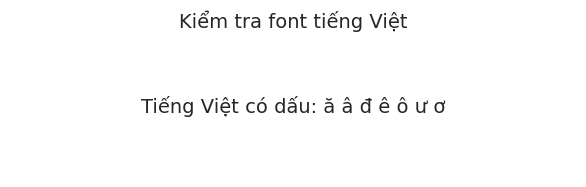

Đã thiết lập xong môi trường tiếng Việt.


In [ ]:
# ============================================
# THIẾT LẬP MÔI TRƯỜNG TIẾNG VIỆT
# ============================================
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# Kiểm tra và cài đặt font hỗ trợ tiếng Việt
# Trên Google Colab, font thường dùng là 'DejaVu Sans' hoặc 'Arial'

# Cách 1: Sử dụng font có sẵn hỗ trợ Unicode
plt.rcParams['font.family'] = 'DejaVu Sans'

# Cách 2: Nếu không hiển thị được, thử font khác
# plt.rcParams['font.family'] = 'Arial'

# Cách 3: Dùng font từ hệ thống (nếu có)
# font_path = '/usr/share/fonts/truetype/liberation/LiberationSans-Regular.ttf'
# font_prop = fm.FontProperties(fname=font_path)
# plt.rcParams['font.family'] = font_prop.get_name()

# Cho phép hiển thị dấu trừ
plt.rcParams['axes.unicode_minus'] = False

# Kiểm tra font đang dùng
print("Font đang sử dụng:", plt.rcParams['font.family'])

# Test hiển thị tiếng Việt
fig, ax = plt.subplots(figsize=(6, 2))
ax.text(0.5, 0.5, 'Tiếng Việt có dấu: ă â đ ê ô ư ơ',
        ha='center', va='center', fontsize=14)
ax.set_title('Kiểm tra font tiếng Việt')
ax.axis('off')
plt.tight_layout()
plt.show()

print("Đã thiết lập xong môi trường tiếng Việt.")

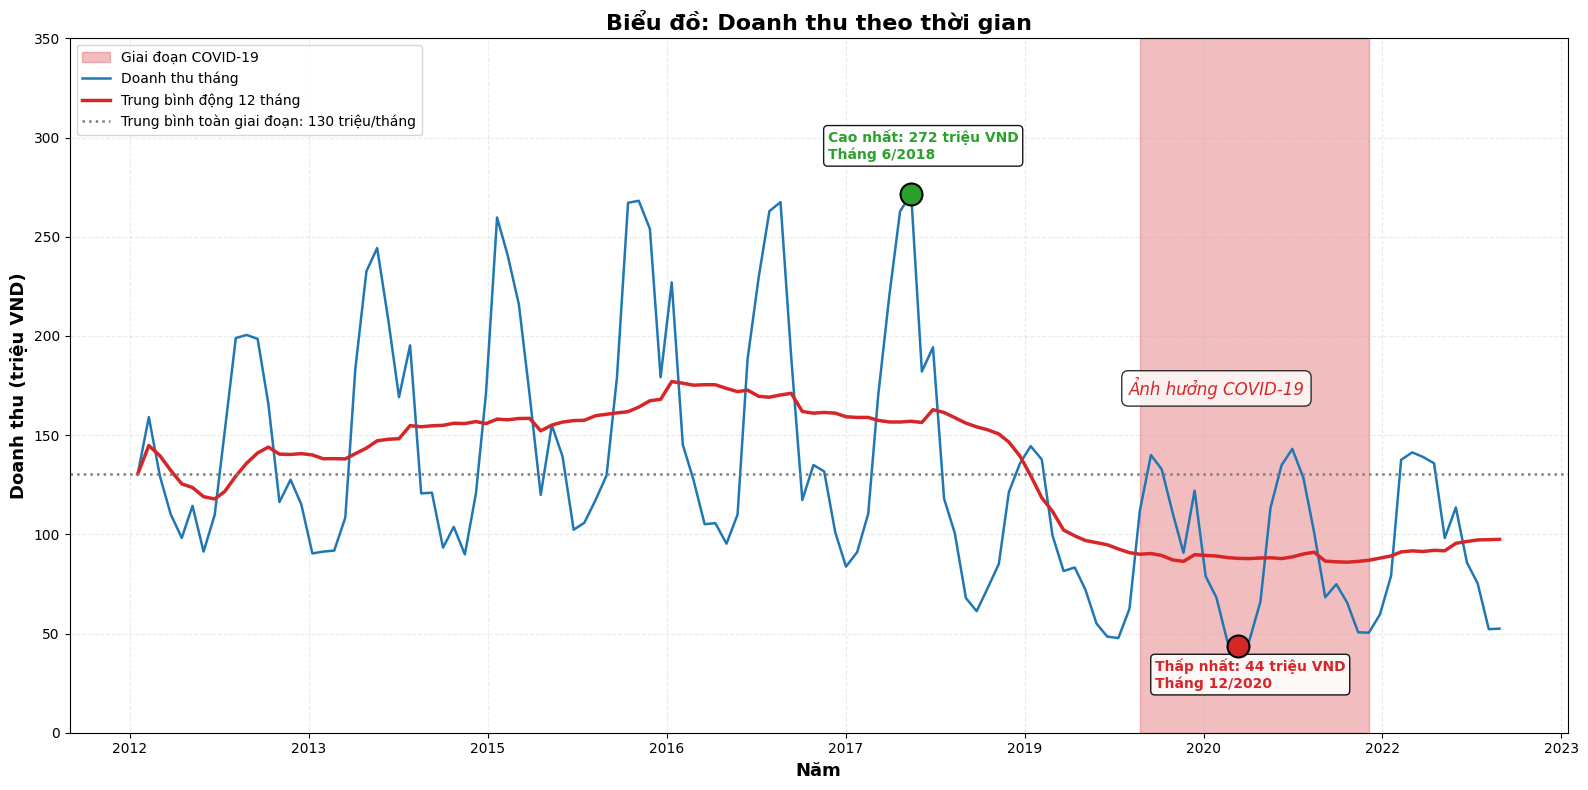


THỐNG KÊ DOANH THU
Tổng doanh thu: 16,430,476,586 VND
Doanh thu trung bình ngày: 4,286,584 VND
Doanh thu trung bình tháng: 130,400,608 VND
Tháng có doanh thu cao nhất: 2018-06 (272 triệu VND)
Tháng có doanh thu thấp nhất: 2020-12 (44 triệu VND)
Chênh lệch cao-thấp: 6.2 lần


In [ ]:
# ============================================
# BIỂU ĐỒ 1: DOANH THU THEO THỜI GIAN
# VỚI CÁC ĐIỂM NHẤN PHÂN TÍCH
# ============================================

# Chuẩn bị dữ liệu
data['sales']['Date'] = pd.to_datetime(data['sales']['Date'])
sales_by_month = data['sales'].groupby(data['sales']['Date'].dt.to_period('M'))['Revenue'].sum().reset_index()
sales_by_month['Date'] = sales_by_month['Date'].dt.to_timestamp()
sales_by_month['Revenue_M'] = sales_by_month['Revenue'] / 1e6

# Tính rolling average 12 tháng
sales_by_month['Rolling_12M'] = sales_by_month['Revenue'].rolling(window=12, min_periods=1).mean() / 1e6

# Xác định các vùng đặc biệt
covid_start = '2020-03'
covid_end = '2021-12'
peak_date = '2018-06'
low_date = '2020-12'

# Tạo figure với kích thước lớn hơn để tránh chồng chữ
fig, ax = plt.subplots(figsize=(16, 8))

# Vẽ vùng nền cho giai đoạn COVID-19
ax.axvspan(pd.to_datetime(covid_start), pd.to_datetime(covid_end),
           alpha=0.3, color=COLOR_HIGHLIGHT, label='Giai đoạn COVID-19')

# Vẽ đường doanh thu
ax.plot(sales_by_month['Date'], sales_by_month['Revenue_M'],
        color=COLOR_PRIMARY, linewidth=1.8, label='Doanh thu tháng')

# Vẽ đường trung bình động
ax.plot(sales_by_month['Date'], sales_by_month['Rolling_12M'],
        color=COLOR_HIGHLIGHT, linewidth=2.5, linestyle='-',
        label='Trung bình động 12 tháng')

# Đánh dấu điểm cao nhất
peak_data = sales_by_month[sales_by_month['Date'].dt.strftime('%Y-%m') == peak_date]
if not peak_data.empty:
    ax.scatter(peak_data['Date'], peak_data['Revenue_M'],
               color=COLOR_SUCCESS, s=250, zorder=5, edgecolor='black', linewidth=1.5)
    ax.annotate(f'Cao nhất: {peak_data["Revenue_M"].values[0]:.0f} triệu VND\nTháng 6/2018',
                xy=(peak_data['Date'].values[0], peak_data['Revenue_M'].values[0]),
                xytext=(-60, 25), textcoords='offset points',
                fontsize=10, fontweight='bold', color=COLOR_SUCCESS,
                bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.9))

# Đánh dấu điểm thấp nhất
low_data = sales_by_month[sales_by_month['Date'].dt.strftime('%Y-%m') == low_date]
if not low_data.empty:
    ax.scatter(low_data['Date'], low_data['Revenue_M'],
               color=COLOR_HIGHLIGHT, s=250, zorder=5, edgecolor='black', linewidth=1.5)
    ax.annotate(f'Thấp nhất: {low_data["Revenue_M"].values[0]:.0f} triệu VND\nTháng 12/2020',
                xy=(low_data['Date'].values[0], low_data['Revenue_M'].values[0]),
                xytext=(-60, -30), textcoords='offset points',
                fontsize=10, fontweight='bold', color=COLOR_HIGHLIGHT,
                bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.9))

# Thêm chú thích cho vùng COVID
ax.text(pd.to_datetime('2020-10'), 170, 'Ảnh hưởng COVID-19',
        fontsize=12, style='italic', color=COLOR_HIGHLIGHT, ha='center',
        bbox=dict(boxstyle='round,pad=0.4', facecolor='white', alpha=0.8))

# Thêm đường tham chiếu cho mức trung bình
avg_revenue = sales_by_month['Revenue_M'].mean()
ax.axhline(y=avg_revenue, color=COLOR_NEUTRAL, linestyle=':', linewidth=1.8,
           label=f'Trung bình toàn giai đoạn: {avg_revenue:.0f} triệu/tháng')

# Cài đặt trục và nhãn
ax.set_xlabel('Năm', fontsize=13, fontweight='bold')
ax.set_ylabel('Doanh thu (triệu VND)', fontsize=13, fontweight='bold')
ax.set_title('Biểu đồ: Doanh thu theo thời gian',
             fontsize=16, fontweight='bold')
ax.legend(loc='upper left', fontsize=10)
ax.grid(True, alpha=0.25, linestyle='--')
ax.set_ylim(bottom=0, top=350)

# Định dạng trục x chỉ hiển thị năm, xoay nhãn để tránh chồng
from matplotlib.dates import DateFormatter
ax.xaxis.set_major_formatter(DateFormatter('%Y'))
ax.xaxis.set_major_locator(plt.MaxNLocator(10))
plt.xticks(rotation=0)

# Tự động điều chỉnh bố cục
plt.tight_layout()
plt.show()

# In thống kê
print("\n" + "="*60)
print("THỐNG KÊ DOANH THU")
print("="*60)
print(f"Tổng doanh thu: {data['sales']['Revenue'].sum():,.0f} VND")
print(f"Doanh thu trung bình ngày: {data['sales']['Revenue'].mean():,.0f} VND")
print(f"Doanh thu trung bình tháng: {sales_by_month['Revenue'].mean():,.0f} VND")
print(f"Tháng có doanh thu cao nhất: {peak_date} ({peak_data['Revenue_M'].values[0]:.0f} triệu VND)")
print(f"Tháng có doanh thu thấp nhất: {low_date} ({low_data['Revenue_M'].values[0]:.0f} triệu VND)")
print(f"Chênh lệch cao-thấp: {peak_data['Revenue_M'].values[0] / low_data['Revenue_M'].values[0]:.1f} lần")
print("="*60)

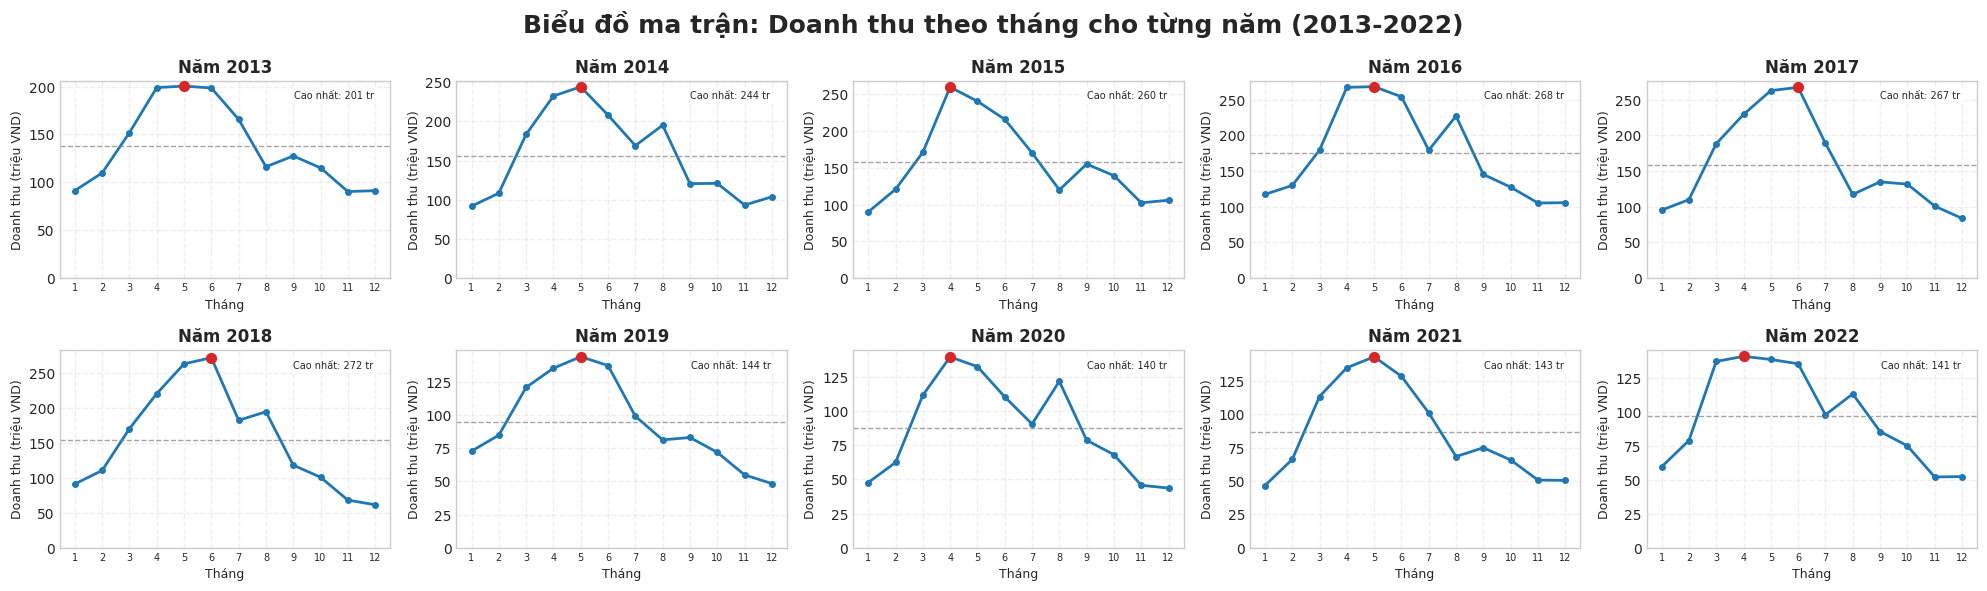


THỐNG KÊ DOANH THU THEO THÁNG CHO TỪNG NĂM
Năm    Tháng cao nhất  Doanh thu cao nhất        Doanh thu TB tháng  
--------------------------------------------------------------------------------
2013   Tháng 5.0                    201 triệu              138 triệu
2014   Tháng 5.0                    244 triệu              156 triệu
2015   Tháng 4.0                    260 triệu              157 triệu
2016   Tháng 5.0                    268 triệu              175 triệu
2017   Tháng 6.0                    267 triệu              159 triệu
2018   Tháng 6.0                    272 triệu              154 triệu
2019   Tháng 5.0                    144 triệu               95 triệu
2020   Tháng 4.0                    140 triệu               88 triệu
2021   Tháng 5.0                    143 triệu               87 triệu
2022   Tháng 4.0                    141 triệu               97 triệu


In [ ]:
# ============================================
# MA TRẬN BIỂU ĐỒ: DOANH THU THEO THÁNG CHO TỪNG NĂM (2013-2022)
# ============================================

# Chuẩn bị dữ liệu
data['sales']['Date'] = pd.to_datetime(data['sales']['Date'])
data['sales']['Year'] = data['sales']['Date'].dt.year
data['sales']['Month'] = data['sales']['Date'].dt.month

# Tổng hợp doanh thu theo năm và tháng
monthly_by_year = data['sales'].groupby(['Year', 'Month'])['Revenue'].sum().reset_index()
monthly_by_year['Revenue_trieu'] = monthly_by_year['Revenue'] / 1_000_000

# Lọc các năm từ 2013 đến 2022 (bỏ 2012 vì không đủ tháng)
years = sorted(monthly_by_year['Year'].unique())
years = [y for y in years if y >= 2013]

# Sắp xếp thành ma trận 2x5 hoặc 3x4
n_cols = 5
n_rows = (len(years) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 3 * n_rows))
axes = axes.flatten()  # Chuyển thành mảng 1 chiều

# Màu sắc chung cho tất cả các năm
color_cycle = plt.cm.Blues(np.linspace(0.4, 0.9, 12))

for idx, year in enumerate(years):
    ax = axes[idx]
    data_year = monthly_by_year[monthly_by_year['Year'] == year]

    # Vẽ đường doanh thu theo tháng
    ax.plot(data_year['Month'], data_year['Revenue_trieu'],
            color=COLOR_PRIMARY, linewidth=2, marker='o', markersize=4)

    # Đánh dấu điểm cao nhất trong năm
    max_month = data_year.loc[data_year['Revenue_trieu'].idxmax()]
    ax.scatter(max_month['Month'], max_month['Revenue_trieu'],
               color=COLOR_HIGHLIGHT, s=50, zorder=5)

    # Tiêu đề và nhãn
    ax.set_title(f'Năm {year}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Tháng', fontsize=9)
    ax.set_ylabel('Doanh thu (triệu VND)', fontsize=9)
    ax.set_xticks(range(1, 13))
    ax.set_xticklabels(range(1, 13), fontsize=7)
    ax.grid(True, alpha=0.3, axis='both', linestyle='--')
    ax.set_ylim(bottom=0)

    # Thêm đường tham chiếu trung bình năm
    avg_year = data_year['Revenue_trieu'].mean()
    ax.axhline(y=avg_year, color=COLOR_NEUTRAL, linestyle='--', linewidth=1, alpha=0.7)

    # Thêm chú thích doanh thu cao nhất
    ax.text(0.95, 0.95, f'Cao nhất: {max_month["Revenue_trieu"]:.0f} tr',
            transform=ax.transAxes, fontsize=7, ha='right', va='top',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))

# Ẩn các subplot thừa (nếu có)
for idx in range(len(years), len(axes)):
    axes[idx].set_visible(False)

plt.suptitle('Biểu đồ ma trận: Doanh thu theo tháng cho từng năm (2013-2022)',
             fontsize=18, fontweight='bold')
plt.tight_layout()
plt.show()

# In thống kê tổng hợp
print("\n" + "="*80)
print("THỐNG KÊ DOANH THU THEO THÁNG CHO TỪNG NĂM")
print("="*80)
print(f"{'Năm':<6} {'Tháng cao nhất':<15} {'Doanh thu cao nhất':<25} {'Doanh thu TB tháng':<20}")
print("-"*80)
for year in years:
    data_year = monthly_by_year[monthly_by_year['Year'] == year]
    max_row = data_year.loc[data_year['Revenue_trieu'].idxmax()]
    print(f"{year:<6} Tháng {max_row['Month']:<10} {max_row['Revenue_trieu']:>15,.0f} triệu     {data_year['Revenue_trieu'].mean():>12,.0f} triệu")
print("="*80)

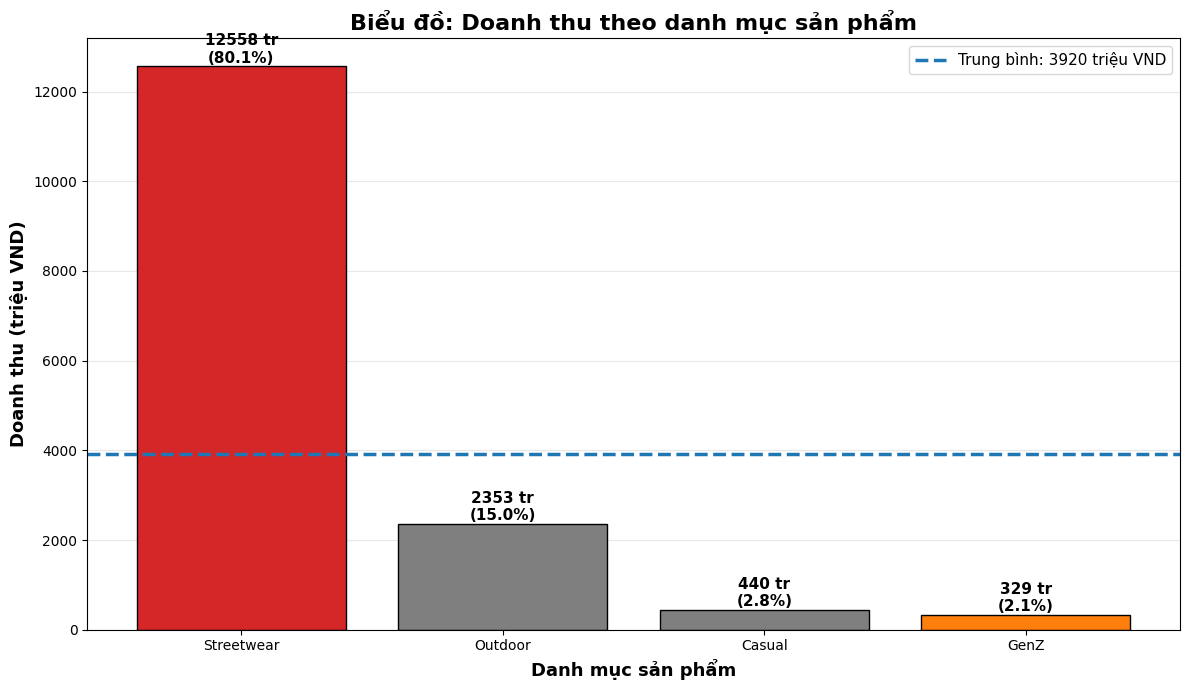


THỐNG KÊ DOANH THU THEO DANH MỤC
Streetwear: 12558 triệu VND (80.1%)
Outdoor: 2353 triệu VND (15.0%)
Casual: 440 triệu VND (2.8%)
GenZ: 329 triệu VND (2.1%)
----------------------------------------
TỔNG DOANH THU: 15,680,869,265 VND
Doanh thu trung bình một danh mục: 3920 triệu VND
Số danh mục có doanh thu trên trung bình: 1 danh mục
Số danh mục có doanh thu dưới trung bình: 3 danh mục


In [ ]:
# ============================================
# BIỂU ĐỒ 3: DOANH THU THEO DANH MỤC SẢN PHẨM (CÓ ĐƯỜNG TRUNG BÌNH)
# ============================================

# Tính doanh thu theo danh mục
order_items_with_cat = data['order_items'].merge(
    data['products'][['product_id', 'category']],
    on='product_id',
    how='left'
)

# Tính doanh thu từng dòng
order_items_with_cat['revenue'] = (
    order_items_with_cat['quantity'] * order_items_with_cat['unit_price'] -
    order_items_with_cat['discount_amount']
)

# Tổng hợp theo danh mục
category_revenue = order_items_with_cat.groupby('category')['revenue'].sum().sort_values(ascending=False)
category_revenue_trieu = category_revenue / 1_000_000
category_percent = (category_revenue / category_revenue.sum()) * 100

# Tính doanh thu trung bình của một danh mục
revenue_avg = category_revenue_trieu.mean()

# Tạo figure
fig, ax = plt.subplots(figsize=(12, 7))

# Màu sắc: nổi bật danh mục cao nhất, thấp nhất màu khác
mau_sac = []
for i, cat in enumerate(category_revenue.index):
    if i == 0:
        mau_sac.append(COLOR_HIGHLIGHT)           # Cao nhất: màu đỏ
    elif i == len(category_revenue) - 1:
        mau_sac.append(COLOR_SECONDARY)             # Thấp nhất: màu cam
    else:
        mau_sac.append(COLOR_NEUTRAL)        # Còn lại: màu xám

bars = ax.bar(category_revenue.index, category_revenue_trieu, color=mau_sac, edgecolor='black', linewidth=1)

# Vẽ đường trung bình
ax.axhline(y=revenue_avg, color=COLOR_PRIMARY, linestyle='--', linewidth=2.5,
           label=f'Trung bình: {revenue_avg:.0f} triệu VND')

# Tiêu đề và nhãn
ax.set_xlabel('Danh mục sản phẩm', fontsize=13, fontweight='bold')
ax.set_ylabel('Doanh thu (triệu VND)', fontsize=13, fontweight='bold')
ax.set_title('Biểu đồ: Doanh thu theo danh mục sản phẩm', fontsize=16, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')
ax.set_axisbelow(True)
ax.legend(loc='upper right', fontsize=11)

# Thêm nhãn số liệu trên đầu mỗi cột
for bar, rev, pct in zip(bars, category_revenue_trieu, category_percent):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
            f'{rev:.0f} tr\n({pct:.1f}%)',
            ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

# In thống kê
print("\n" + "="*60)
print("THỐNG KÊ DOANH THU THEO DANH MỤC")
print("="*60)
for cat, rev, pct in zip(category_revenue.index, category_revenue_trieu, category_percent):
    print(f"{cat}: {rev:.0f} triệu VND ({pct:.1f}%)")
print("-"*40)
print(f"TỔNG DOANH THU: {category_revenue.sum():,.0f} VND")
print(f"Doanh thu trung bình một danh mục: {revenue_avg:.0f} triệu VND")
print(f"Số danh mục có doanh thu trên trung bình: {(category_revenue_trieu > revenue_avg).sum()} danh mục")
print(f"Số danh mục có doanh thu dưới trung bình: {(category_revenue_trieu < revenue_avg).sum()} danh mục")
print("="*60)

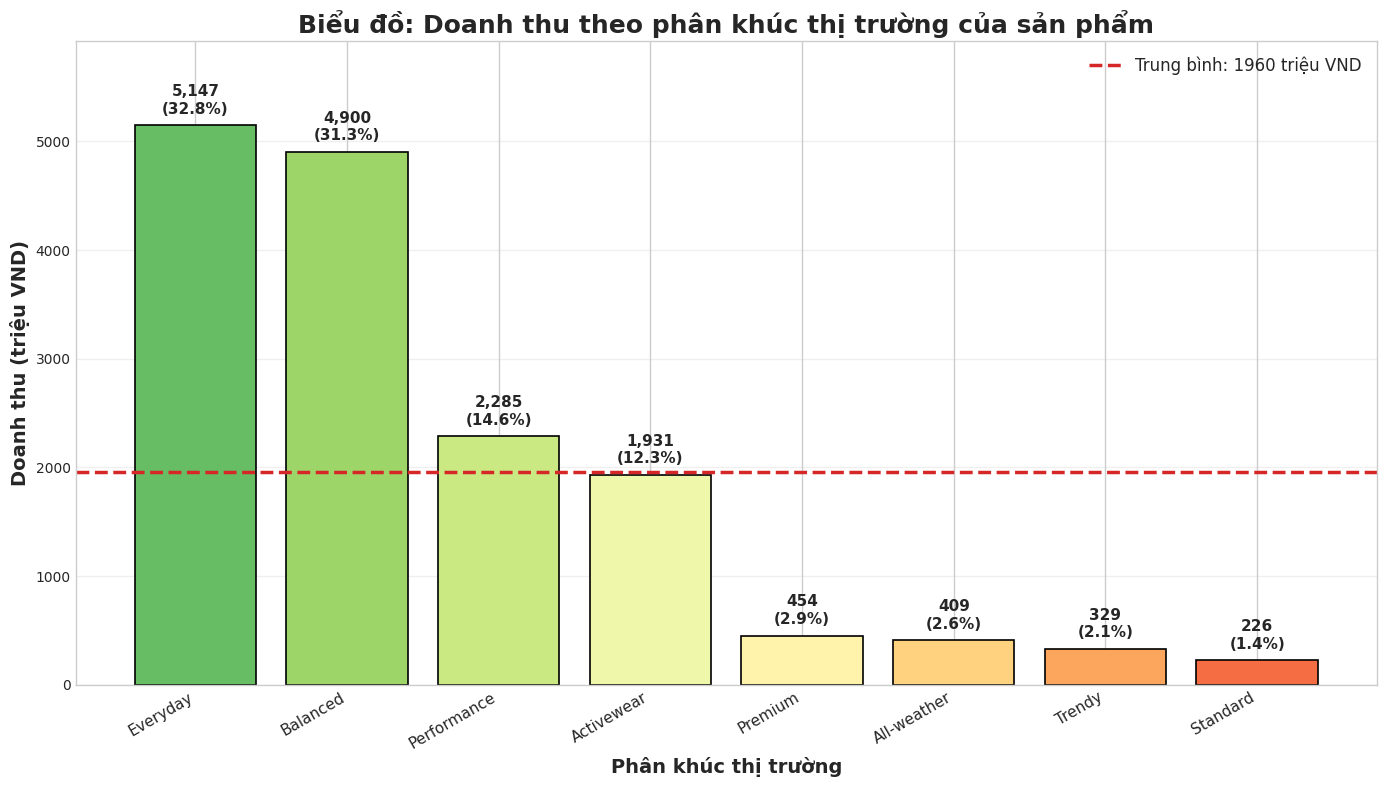


THỐNG KÊ DOANH THU THEO PHÂN KHÚC THỊ TRƯỜNG
Phân khúc       Doanh thu (triệu VND)     Tỷ lệ     
----------------------------------------------------------------------
Everyday                       5,147 triệu      32.8%
Balanced                       4,900 triệu      31.3%
Performance                    2,285 triệu      14.6%
Activewear                     1,931 triệu      12.3%
Premium                          454 triệu       2.9%
All-weather                      409 triệu       2.6%
Trendy                           329 triệu       2.1%
Standard                         226 triệu       1.4%
----------------------------------------------------------------------
TỔNG CỘNG             15,680,869,265 VND
Phân khúc cao nhất Everyday (5147 triệu, 32.8%)
Phân khúc thấp nhất Standard (226 triệu, 1.4%)
Chênh lệch      22.8 lần


In [ ]:
# ============================================
# BIỂU ĐỒ: DOANH THU THEO PHÂN KHÚC THỊ TRƯỜNG
# ============================================

# Lấy thông tin phân khúc của sản phẩm
products_segment = data['products'][['product_id', 'segment']]

# Join order_items với products để có segment
order_items_with_segment = data['order_items'].merge(
    products_segment,
    on='product_id',
    how='left'
)

# Tính doanh thu từng dòng
order_items_with_segment['revenue'] = (
    order_items_with_segment['quantity'] * order_items_with_segment['unit_price'] -
    order_items_with_segment['discount_amount']
)

# Tổng hợp theo phân khúc
segment_revenue = order_items_with_segment.groupby('segment')['revenue'].sum().sort_values(ascending=False)
segment_revenue_trieu = segment_revenue / 1_000_000
segment_percent = (segment_revenue / segment_revenue.sum()) * 100

# Tạo figure với kích thước lớn
fig, ax = plt.subplots(figsize=(14, 8))

# Màu sắc: gradient từ đậm đến nhạt theo thứ tự doanh thu
colors = plt.cm.RdYlGn_r(np.linspace(0.2, 0.8, len(segment_revenue)))

bars = ax.bar(segment_revenue.index, segment_revenue_trieu, color=colors, edgecolor='black', linewidth=1.2)

# Tính giá trị trung bình
avg_segment = segment_revenue_trieu.mean()
ax.axhline(y=avg_segment, color='#d62728', linestyle='--', linewidth=2.5,
           label=f'Trung bình: {avg_segment:.0f} triệu VND')

# Tiêu đề và nhãn
ax.set_xlabel('Phân khúc thị trường', fontsize=14, fontweight='bold')
ax.set_ylabel('Doanh thu (triệu VND)', fontsize=14, fontweight='bold')
ax.set_title('Biểu đồ: Doanh thu theo phân khúc thị trường của sản phẩm', fontsize=18, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')
ax.set_axisbelow(True)
ax.legend(loc='upper right', fontsize=12)

# Thêm nhãn số liệu trên đầu mỗi cột
for bar, rev, pct in zip(bars, segment_revenue_trieu, segment_percent):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 80,
            f'{rev:,.0f}\n({pct:.1f}%)',
            ha='center', va='bottom', fontsize=11, fontweight='bold')

# Xoay nhãn trục x để tránh chồng
plt.xticks(rotation=30, ha='right', fontsize=11)

# Điều chỉnh giới hạn trục y
ax.set_ylim(0, max(segment_revenue_trieu) * 1.15)

plt.tight_layout()
plt.show()

# In thống kê chi tiết
print("\n" + "="*70)
print("THỐNG KÊ DOANH THU THEO PHÂN KHÚC THỊ TRƯỜNG")
print("="*70)
print(f"{'Phân khúc':<15} {'Doanh thu (triệu VND)':<25} {'Tỷ lệ':<10}")
print("-"*70)
for seg, rev, pct in zip(segment_revenue.index, segment_revenue_trieu, segment_percent):
    print(f"{seg:<15} {rev:>20,.0f} triệu     {pct:>5.1f}%")
print("-"*70)
print(f"{'TỔNG CỘNG':<15} {segment_revenue.sum():>20,.0f} VND")
print(f"{'Phân khúc cao nhất':<15} {segment_revenue.index[0]} ({segment_revenue_trieu.iloc[0]:.0f} triệu, {segment_percent.iloc[0]:.1f}%)")
print(f"{'Phân khúc thấp nhất':<15} {segment_revenue.index[-1]} ({segment_revenue_trieu.iloc[-1]:.0f} triệu, {segment_percent.iloc[-1]:.1f}%)")
print(f"{'Chênh lệch':<15} {segment_revenue.iloc[0] / segment_revenue.iloc[-1]:.1f} lần")
print("="*70)

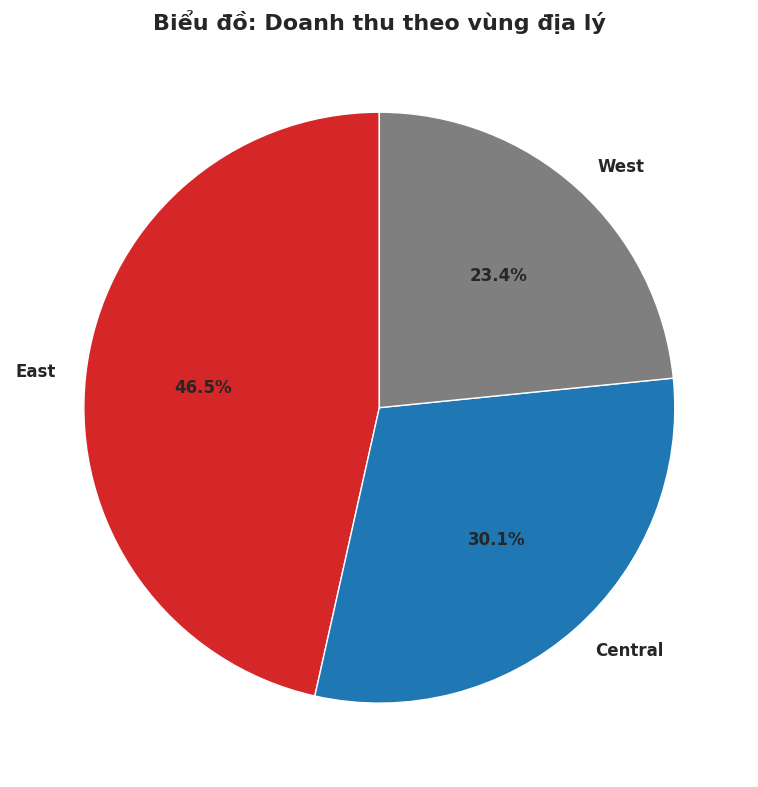


DOANH THU THEO VÙNG:
East: 7291 triệu VND (46.5%)
Central: 4719 triệu VND (30.1%)
West: 3670 triệu VND (23.4%)


In [ ]:
# ============================================
# BIỂU ĐỒ: DOANH THU THEO VÙNG ĐỊA LÝ
# ============================================

# Join orders với geography để lấy region
orders_with_region = data['orders'].merge(
    data['geography'][['zip', 'region']],
    on='zip',
    how='left'
)

# Join với order_items để tính doanh thu
orders_with_region = orders_with_region.merge(
    data['order_items'][['order_id', 'quantity', 'unit_price', 'discount_amount']],
    on='order_id',
    how='left'
)

# Tính doanh thu
orders_with_region['revenue'] = (
    orders_with_region['quantity'] * orders_with_region['unit_price'] -
    orders_with_region['discount_amount']
)

# Tổng hợp theo vùng
region_revenue = orders_with_region.groupby('region')['revenue'].sum().sort_values(ascending=False)
region_revenue_trieu = region_revenue / 1_000_000
region_percent = (region_revenue / region_revenue.sum()) * 100

# Vẽ biểu đồ tròn
fig, ax = plt.subplots(figsize=(10, 8))
colors = [COLOR_HIGHLIGHT, COLOR_PRIMARY, COLOR_NEUTRAL]
wedges, texts, autotexts = ax.pie(region_revenue.values, labels=region_revenue.index,
                                    autopct='%1.1f%%', colors=colors, startangle=90,
                                    textprops={'fontsize': 12, 'fontweight': 'bold'})
ax.set_title('Biểu đồ: Doanh thu theo vùng địa lý', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nDOANH THU THEO VÙNG:")
for region, rev, pct in zip(region_revenue.index, region_revenue_trieu, region_percent):
    print(f"{region}: {rev:.0f} triệu VND ({pct:.1f}%)")

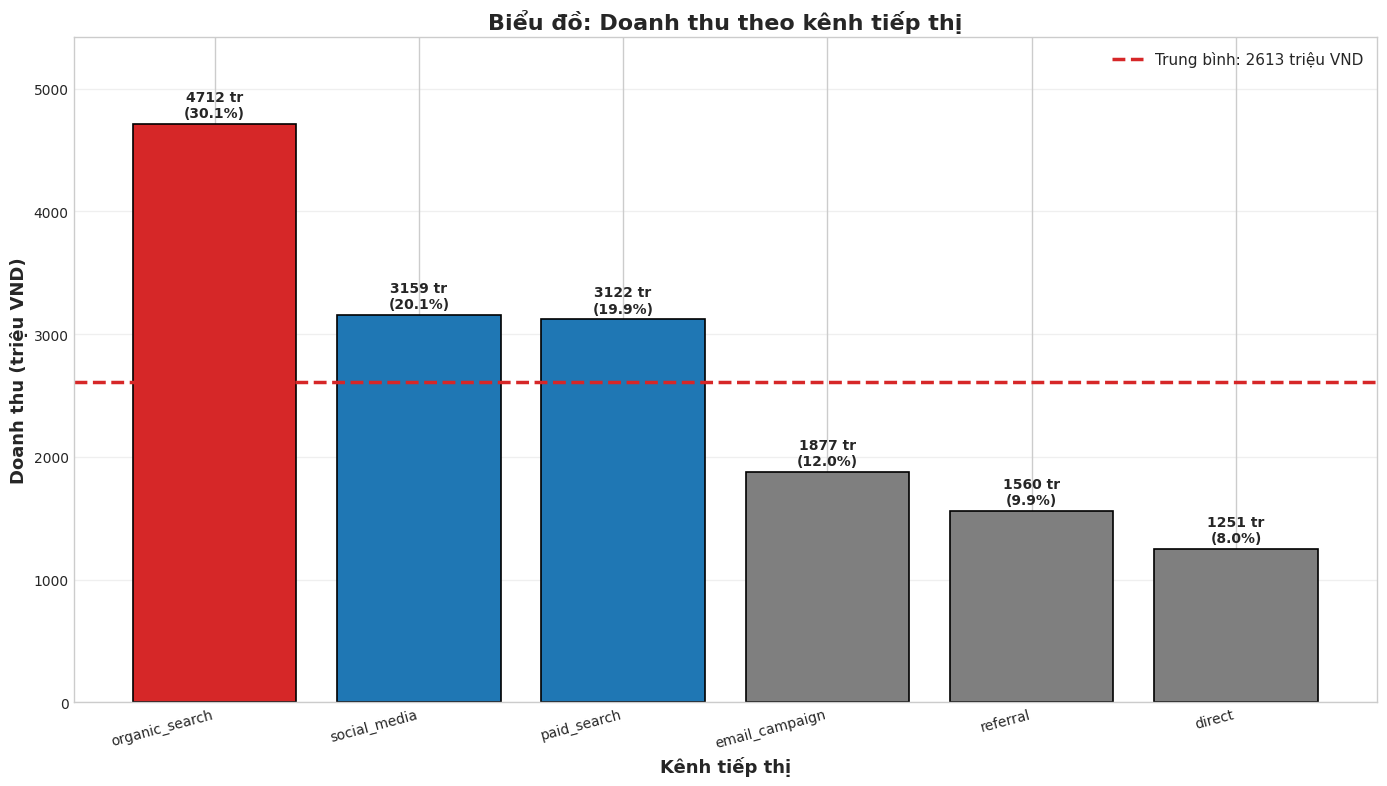


THỐNG KÊ DOANH THU THEO KÊNH TIẾP THỊ
Doanh thu trung bình một kênh: 2613 triệu VND
----------------------------------------------------------------------
Kênh               Doanh thu            So với TB      
----------------------------------------------------------------------
organic_search            4,712 triệu (30.1%)   ▲ Cao hơn
social_media              3,159 triệu (20.1%)   ▲ Cao hơn
paid_search               3,122 triệu (19.9%)   ▲ Cao hơn
email_campaign            1,877 triệu (12.0%)   ▼ Thấp hơn
referral                  1,560 triệu (9.9%)   ▼ Thấp hơn
direct                    1,251 triệu (8.0%)   ▼ Thấp hơn


In [ ]:
# ============================================
# BIỂU ĐỒ: DOANH THU THEO KÊNH TIẾP THỊ (CÓ ĐƯỜNG TRUNG BÌNH)
# ============================================

# Lấy thông tin khách hàng
customer_channel = data['customers'][['customer_id', 'acquisition_channel']]

# Join orders với customers
orders_with_channel = data['orders'].merge(customer_channel, on='customer_id', how='left')

# Join với order_items
orders_with_channel = orders_with_channel.merge(
    data['order_items'][['order_id', 'quantity', 'unit_price', 'discount_amount']],
    on='order_id',
    how='left'
)

# Tính doanh thu
orders_with_channel['revenue'] = (
    orders_with_channel['quantity'] * orders_with_channel['unit_price'] -
    orders_with_channel['discount_amount']
)

# Bỏ qua null
orders_with_channel = orders_with_channel[orders_with_channel['acquisition_channel'].notna()]

# Tổng hợp doanh thu theo kênh
channel_revenue = orders_with_channel.groupby('acquisition_channel')['revenue'].sum().sort_values(ascending=False)
channel_revenue_trieu = channel_revenue / 1_000_000
channel_percent = (channel_revenue / channel_revenue.sum()) * 100

# Tính giá trị trung bình của một kênh
avg_revenue = channel_revenue_trieu.mean()

# Tạo figure
fig, ax = plt.subplots(figsize=(14, 8))

# Màu sắc: nổi bật kênh cao nhất, các kênh còn lại màu xanh
colors = []
for i, (channel, rev) in enumerate(zip(channel_revenue.index, channel_revenue_trieu)):
    if rev == channel_revenue_trieu.max():
        colors.append(COLOR_HIGHLIGHT)  # Kênh cao nhất màu đỏ
    elif rev < avg_revenue:
        colors.append(COLOR_NEUTRAL)  # Kênh dưới trung bình màu xám
    else:
        colors.append(COLOR_PRIMARY)  # Kênh trên trung bình màu xanh

bars = ax.bar(channel_revenue.index, channel_revenue_trieu, color=colors, edgecolor='black', linewidth=1.2)

# Vẽ đường trung bình
ax.axhline(y=avg_revenue, color=COLOR_HIGHLIGHT, linestyle='--', linewidth=2.5,
           label=f'Trung bình: {avg_revenue:.0f} triệu VND')

# Tiêu đề và nhãn
ax.set_xlabel('Kênh tiếp thị', fontsize=13, fontweight='bold')
ax.set_ylabel('Doanh thu (triệu VND)', fontsize=13, fontweight='bold')
ax.set_title('Biểu đồ: Doanh thu theo kênh tiếp thị',
             fontsize=16, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')
ax.legend(loc='upper right', fontsize=11)
plt.setp(ax.xaxis.get_majorticklabels(), rotation=15, ha='right')

# Thêm nhãn số liệu trên đầu mỗi cột
for bar, rev, pct in zip(bars, channel_revenue_trieu, channel_percent):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
            f'{rev:.0f} tr\n({pct:.1f}%)', ha='center', va='bottom', fontsize=10, fontweight='bold')

# Điều chỉnh giới hạn trục y để có khoảng trống cho nhãn
ax.set_ylim(0, max(channel_revenue_trieu) * 1.15)

plt.tight_layout()
plt.show()

# In thống kê
print("\n" + "="*70)
print("THỐNG KÊ DOANH THU THEO KÊNH TIẾP THỊ")
print("="*70)
print(f"Doanh thu trung bình một kênh: {avg_revenue:.0f} triệu VND")
print("-"*70)
print(f"{'Kênh':<18} {'Doanh thu':<20} {'So với TB':<15}")
print("-"*70)
for channel, rev, pct in zip(channel_revenue.index, channel_revenue_trieu, channel_percent):
    status = "▲ Cao hơn" if rev > avg_revenue else "▼ Thấp hơn" if rev < avg_revenue else "● Bằng"
    print(f"{channel:<18} {rev:>12,.0f} triệu ({pct:.1f}%)   {status}")
print("="*70)

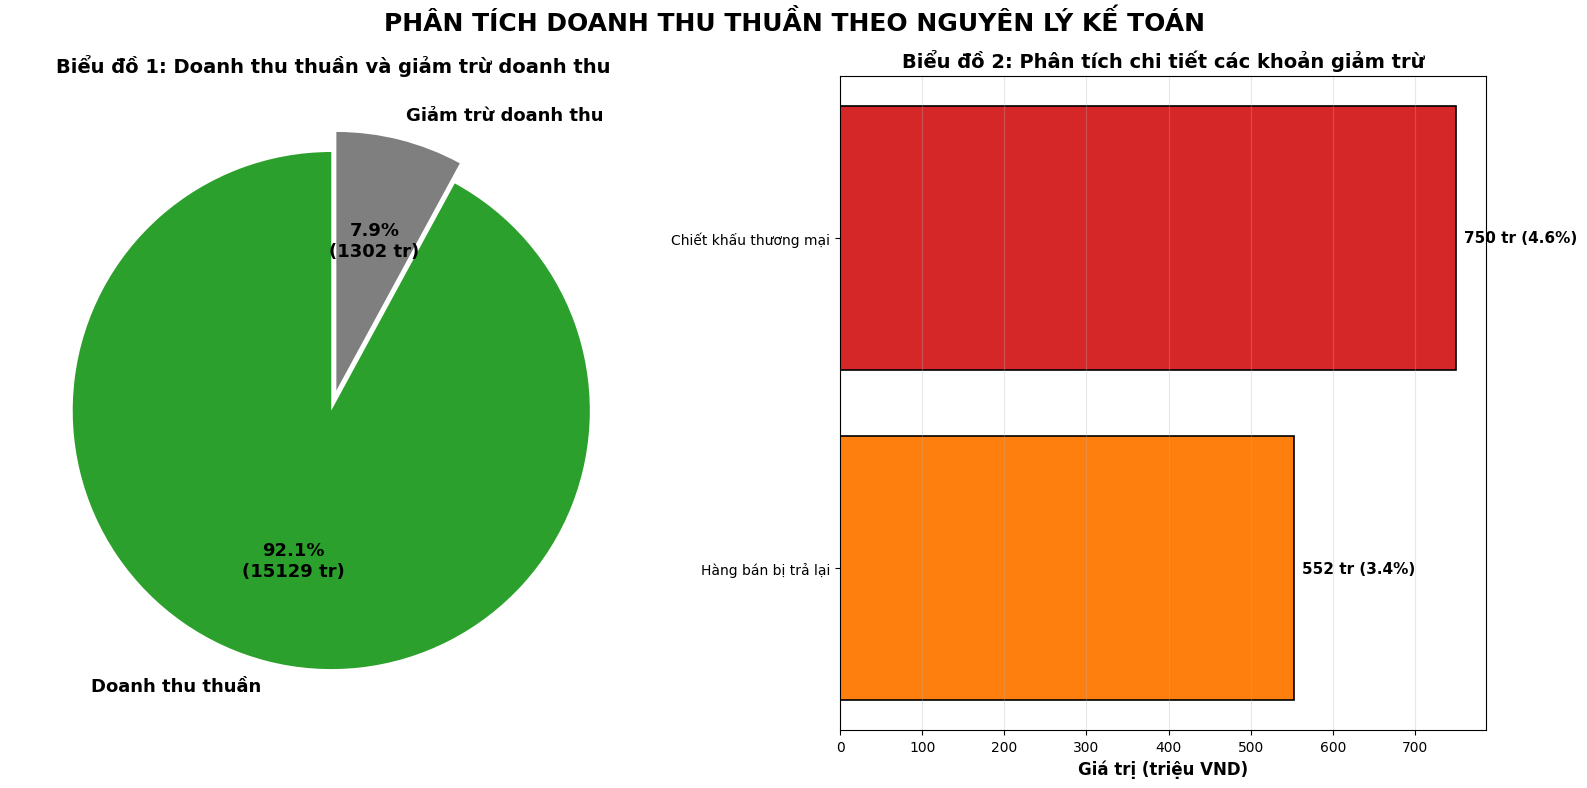


Biểu đồ: Cấu trúc doanh thu
Doanh thu gộp:                               16,430 triệu VND (100.0%)

Các khoản giảm trừ doanh thu:
  - Chiết khấu thương mại (giảm giá):         750 triệu VND (  4.6%)
  - Hàng bán bị trả lại:                      552 triệu VND (  3.4%)
--------------------------------------------------------------------------------
Tổng giảm trừ doanh thu:                      1,302 triệu VND (  7.9%)

DOANH THU THUẦN:                             15,129 triệu VND ( 92.1%)

📌 NHẬN XÉT KẾ TOÁN:
   - Tỷ lệ giảm trừ doanh thu: 7.9%
   - Chiết khấu thương mại chiếm 57.6% tổng giảm trừ
   - Hàng trả lại chiếm 42.4% tổng giảm trừ


In [ ]:
# ============================================
# BIỂU ĐỒ: DOANH THU THUẦN VÀ GIẢM TRỪ DOANH THU
# (DÙNG BẢNG MÀU CHUẨN CỦA BẠN)
# ============================================

# Tone màu chung
COLOR_PRIMARY = '#1f77b4'      # Màu chính: xanh dương
COLOR_SECONDARY = '#ff7f0e'    # Màu phụ: cam
COLOR_HIGHLIGHT = '#d62728'    # Màu nổi bật: đỏ
COLOR_SUCCESS = '#2ca02c'      # Màu thành công: xanh lá
COLOR_NEUTRAL = '#7f7f7f'      # Màu trung tính: xám

# Bước 1: Tính doanh thu gộp
order_items_rev = data['order_items'].copy()
order_items_rev['gross_revenue'] = order_items_rev['quantity'] * order_items_rev['unit_price']
order_items_rev['discount_amount'] = order_items_rev['discount_amount'].fillna(0)

gross_revenue = order_items_rev['gross_revenue'].sum()
total_discount = order_items_rev['discount_amount'].sum()  # Chiết khấu thương mại

# Bước 2: Tính giá trị hàng trả lại
returns_with_value = data['returns'].merge(
    data['order_items'][['order_id', 'product_id', 'unit_price']],
    on=['order_id', 'product_id'],
    how='left'
)
returns_with_value['return_value'] = returns_with_value['return_quantity'] * returns_with_value['unit_price']
total_return_value = returns_with_value['return_value'].sum()

# Bước 3: Tổng giảm trừ doanh thu
total_reduction = total_discount + total_return_value

# Bước 4: Doanh thu thuần
net_revenue = gross_revenue - total_reduction

# Bước 5: Chuẩn bị dữ liệu biểu đồ tròn
pie_data = {
    'Doanh thu thuần': net_revenue,
    'Giảm trừ doanh thu': total_reduction
}

# Phân tích chi tiết các khoản giảm trừ
reduction_detail = {
    'Chiết khấu thương mại': total_discount,
    'Hàng bán bị trả lại': total_return_value
}

pie_values = list(pie_data.values())
pie_labels = list(pie_data.keys())
pie_percent = [v / gross_revenue * 100 for v in pie_values]

# Tạo figure với 2 biểu đồ
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))

# ===== BIỂU ĐỒ 1: TRÒN DOANH THU THUẦN VS GIẢM TRỪ =====
# Dùng màu: xanh lá cho doanh thu thuần, đỏ cho giảm trừ
mau_tron = [COLOR_SUCCESS, COLOR_NEUTRAL]
wedges, texts, autotexts = ax1.pie(
    pie_values,
    labels=pie_labels,
    autopct=lambda pct: f'{pct:.1f}%\n({pct/100 * gross_revenue/1e6:.0f} tr)',
    colors=mau_tron,
    startangle=90,
    explode=(0.03, 0.05),
    textprops={'fontsize': 13, 'fontweight': 'bold'}
)
ax1.set_title('Biểu đồ 1: Doanh thu thuần và giảm trừ doanh thu', fontsize=14, fontweight='bold')

# ===== BIỂU ĐỒ 2: THANH NGANG PHÂN TÍCH CÁC KHOẢN GIẢM TRỪ =====
df_reduction = pd.DataFrame({
    'Khoản mục': list(reduction_detail.keys()),
    'Giá trị (triệu VND)': [v / 1e6 for v in reduction_detail.values()],
    'Tỷ lệ trên doanh thu gộp': [v / gross_revenue * 100 for v in reduction_detail.values()]
})
df_reduction = df_reduction.sort_values('Giá trị (triệu VND)', ascending=True)

# Dùng màu: cam cho chiết khấu, đỏ cho hàng trả lại
mau_thanh = [COLOR_SECONDARY, COLOR_HIGHLIGHT]
bars = ax2.barh(df_reduction['Khoản mục'], df_reduction['Giá trị (triệu VND)'],
                color=mau_thanh, edgecolor='black', linewidth=1.2)
ax2.set_xlabel('Giá trị (triệu VND)', fontsize=12, fontweight='bold')
ax2.set_title('Biểu đồ 2: Phân tích chi tiết các khoản giảm trừ', fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3, axis='x')

for bar, val, pct in zip(bars, df_reduction['Giá trị (triệu VND)'], df_reduction['Tỷ lệ trên doanh thu gộp']):
    ax2.text(bar.get_width() + 10, bar.get_y() + bar.get_height()/2,
             f'{val:.0f} tr ({pct:.1f}%)', va='center', fontsize=11, fontweight='bold')

plt.suptitle('PHÂN TÍCH DOANH THU THUẦN THEO NGUYÊN LÝ KẾ TOÁN', fontsize=18, fontweight='bold')
plt.tight_layout()
plt.show()

# In bảng thống kê
print("\n" + "="*80)
print("Biểu đồ: Cấu trúc doanh thu")
print("="*80)
print(f"Doanh thu gộp:                      {gross_revenue/1e6:>15,.0f} triệu VND (100.0%)")
print("")
print("Các khoản giảm trừ doanh thu:")
print(f"  - Chiết khấu thương mại (giảm giá): {total_discount/1e6:>11,.0f} triệu VND ({total_discount/gross_revenue*100:>5.1f}%)")
print(f"  - Hàng bán bị trả lại:              {total_return_value/1e6:>11,.0f} triệu VND ({total_return_value/gross_revenue*100:>5.1f}%)")
print("-"*80)
print(f"Tổng giảm trừ doanh thu:            {total_reduction/1e6:>15,.0f} triệu VND ({total_reduction/gross_revenue*100:>5.1f}%)")
print("")
print(f"DOANH THU THUẦN:                    {net_revenue/1e6:>15,.0f} triệu VND ({net_revenue/gross_revenue*100:>5.1f}%)")
print("="*80)

# Nhận xét
print(f"\n📌 NHẬN XÉT KẾ TOÁN:")
print(f"   - Tỷ lệ giảm trừ doanh thu: {total_reduction/gross_revenue*100:.1f}%")
print(f"   - Chiết khấu thương mại chiếm {total_discount/total_reduction*100:.1f}% tổng giảm trừ")
print(f"   - Hàng trả lại chiếm {total_return_value/total_reduction*100:.1f}% tổng giảm trừ")
print("="*80)


GIÁ TRỊ ĐƠN HÀNG TRUNG BÌNH (AOV) TỔNG THỂ
Tổng số đơn hàng: 646,945
Tổng doanh thu: 15681 triệu VND
AOV trung bình: 24,238 VND/đơn


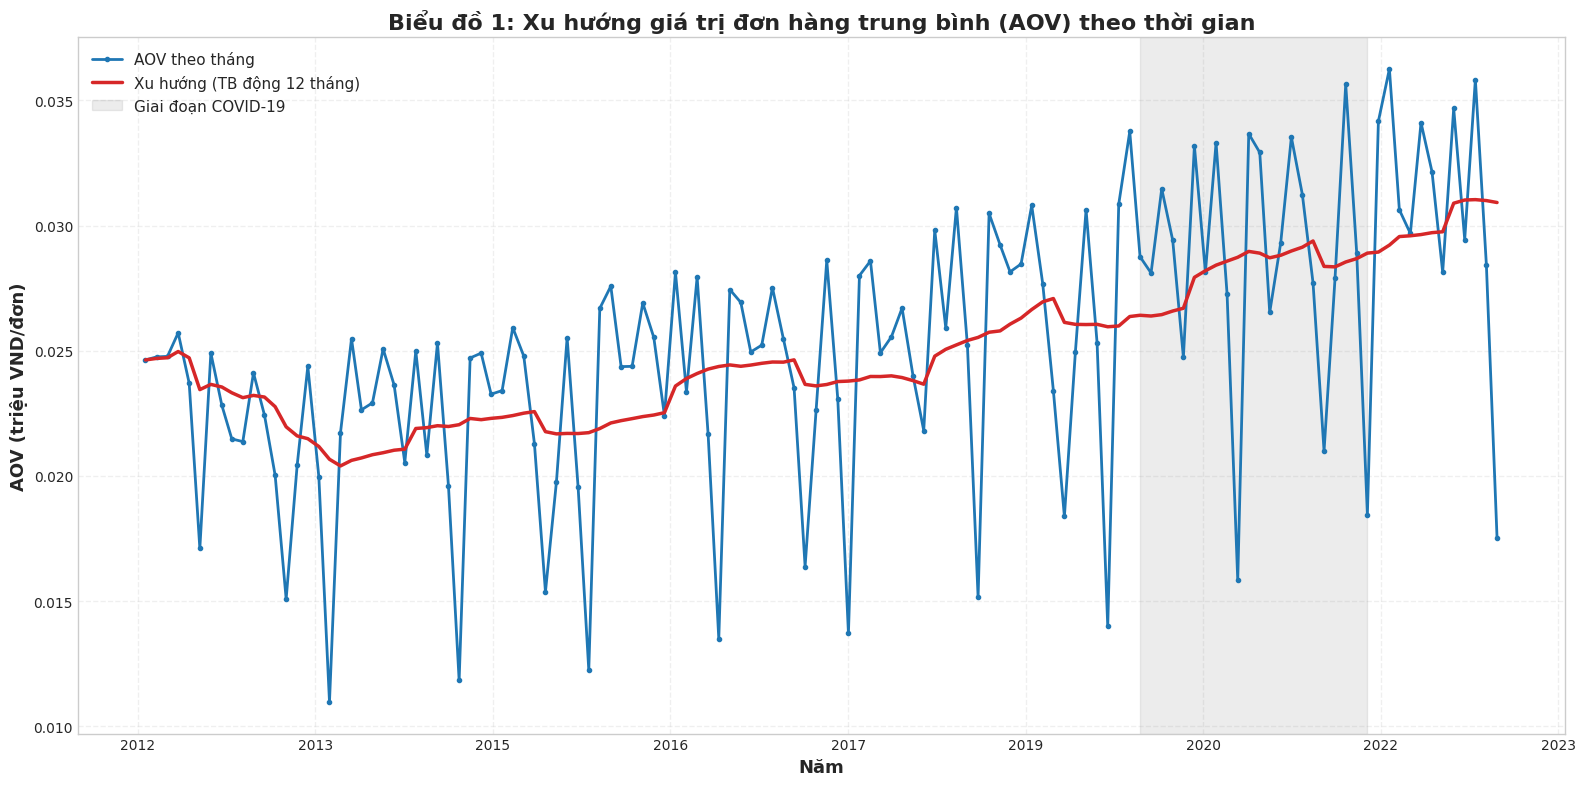

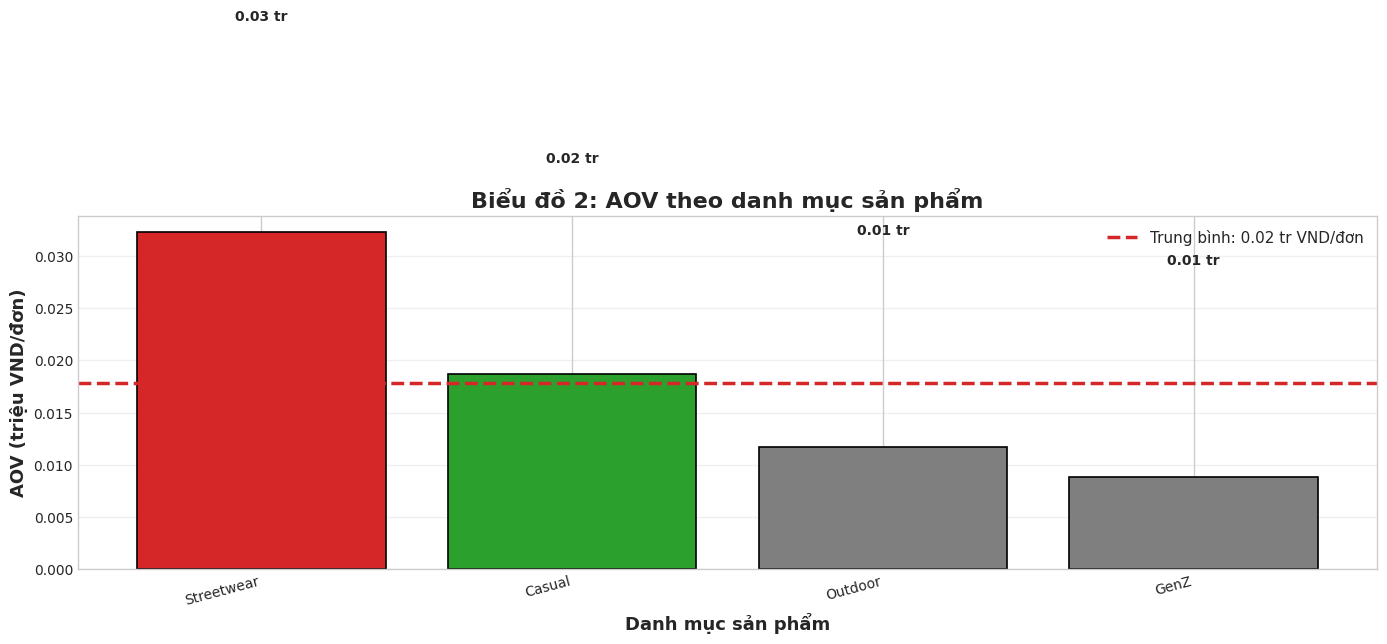

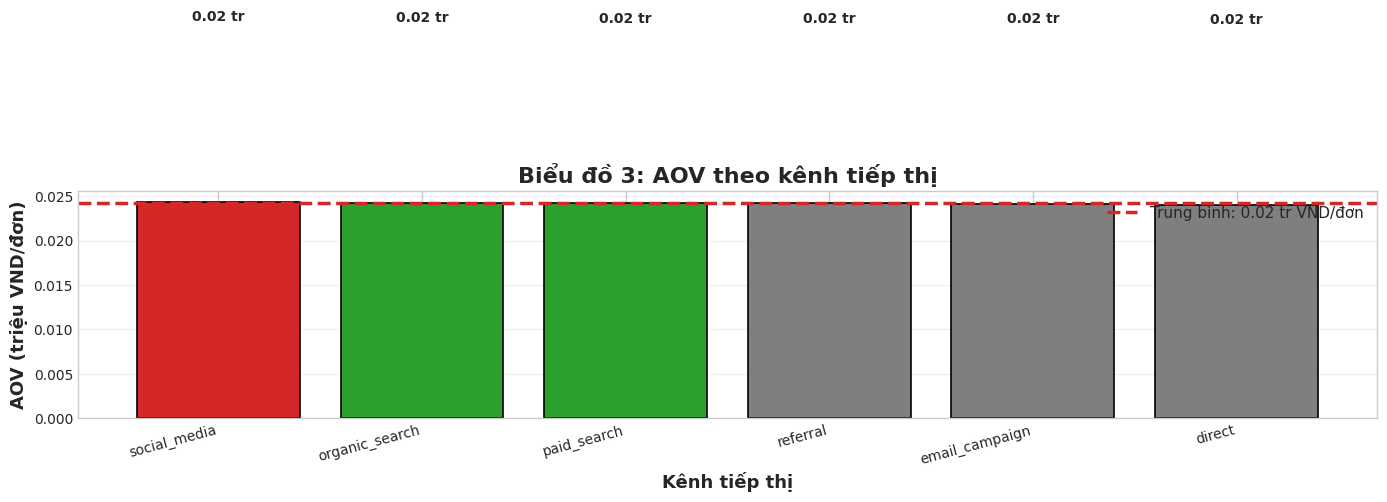

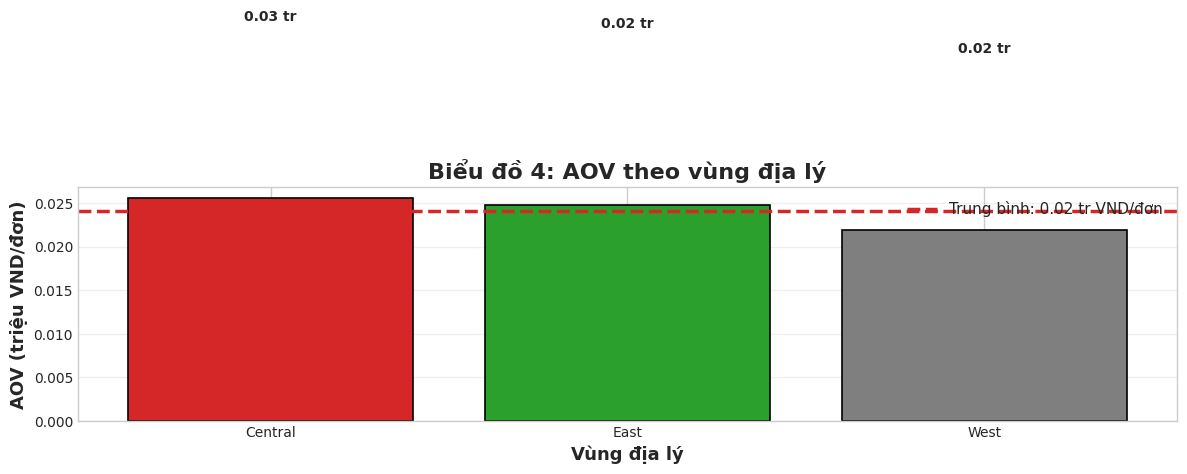


TỔNG HỢP AOV THEO CÁC GÓC NHÌN
AOV TOÀN DOANH NGHIỆP: 24,238 VND/đơn

1. THEO DANH MỤC SẢN PHẨM:
   - Streetwear: 32,239 VND/đơn
   - Casual: 18,656 VND/đơn
   - Outdoor: 11,740 VND/đơn
   - GenZ: 8,871 VND/đơn

2. THEO KÊNH TIẾP THỊ:
   - social_media: 24,391 VND/đơn
   - organic_search: 24,261 VND/đơn
   - paid_search: 24,213 VND/đơn
   - referral: 24,196 VND/đơn
   - email_campaign: 24,133 VND/đơn
   - direct: 24,045 VND/đơn

3. THEO VÙNG ĐỊA LÝ:
   - Central: 25,553 VND/đơn
   - East: 24,748 VND/đơn
   - West: 21,893 VND/đơn


In [ ]:
# ============================================
# PHÂN TÍCH GIÁ TRỊ ĐƠN HÀNG TRUNG BÌNH (AOV)
# ============================================

# Tone màu chung
COLOR_PRIMARY = '#1f77b4'      # Xanh dương
COLOR_SECONDARY = '#ff7f0e'    # Cam
COLOR_HIGHLIGHT = '#d62728'    # Đỏ
COLOR_SUCCESS = '#2ca02c'      # Xanh lá
COLOR_NEUTRAL = '#7f7f7f'      # Xám

# ============================================
# BƯỚC 1: TÍNH AOV TỔNG THỂ
# ============================================

# Tính doanh thu theo từng đơn hàng
order_revenue = data['order_items'].groupby('order_id').apply(
    lambda x: (x['quantity'] * x['unit_price'] - x['discount_amount'].fillna(0)).sum()
).reset_index(name='order_value')

# Thống kê AOV tổng thể
total_orders = len(order_revenue)
total_revenue = order_revenue['order_value'].sum()
aov_overall = total_revenue / total_orders

print("\n" + "="*70)
print("GIÁ TRỊ ĐƠN HÀNG TRUNG BÌNH (AOV) TỔNG THỂ")
print("="*70)
print(f"Tổng số đơn hàng: {total_orders:,}")
print(f"Tổng doanh thu: {total_revenue/1e6:.0f} triệu VND")
print(f"AOV trung bình: {aov_overall:,.0f} VND/đơn")
print("="*70)

# ============================================
# BIỂU ĐỒ 1: AOV THEO THỜI GIAN (XU HƯỚNG)
# ============================================

# Lấy ngày đặt hàng
order_date = data['orders'][['order_id', 'order_date']]
order_date['order_date'] = pd.to_datetime(order_date['order_date'])
order_with_date = order_revenue.merge(order_date, on='order_id')

# Tính AOV theo tháng
order_with_date['year_month'] = order_with_date['order_date'].dt.to_period('M')
aov_by_month = order_with_date.groupby('year_month')['order_value'].mean().reset_index()
aov_by_month['date'] = aov_by_month['year_month'].dt.to_timestamp()
aov_by_month['aov_trieu'] = aov_by_month['order_value'] / 1_000_000

# Tính trung bình động 12 tháng
aov_by_month['rolling_avg'] = aov_by_month['order_value'].rolling(window=12, min_periods=1).mean() / 1_000_000

fig, ax = plt.subplots(figsize=(16, 8))
ax.plot(aov_by_month['date'], aov_by_month['aov_trieu'],
        color=COLOR_PRIMARY, linewidth=2, marker='o', markersize=3, label='AOV theo tháng')
ax.plot(aov_by_month['date'], aov_by_month['rolling_avg'],
        color=COLOR_HIGHLIGHT, linewidth=2.5, linestyle='-', label='Xu hướng (TB động 12 tháng)')

# Vùng COVID
covid_start = pd.to_datetime('2020-03-01')
covid_end = pd.to_datetime('2021-12-01')
ax.axvspan(covid_start, covid_end, alpha=0.15, color='gray', label='Giai đoạn COVID-19')

ax.set_xlabel('Năm', fontsize=13, fontweight='bold')
ax.set_ylabel('AOV (triệu VND/đơn)', fontsize=13, fontweight='bold')
ax.set_title('Biểu đồ 1: Xu hướng giá trị đơn hàng trung bình (AOV) theo thời gian',
             fontsize=16, fontweight='bold')
ax.legend(loc='upper left', fontsize=11)
ax.grid(True, alpha=0.3, linestyle='--')

from matplotlib.dates import DateFormatter
ax.xaxis.set_major_formatter(DateFormatter('%Y'))
ax.xaxis.set_major_locator(plt.MaxNLocator(10))

plt.tight_layout()
plt.show()

# ============================================
# BIỂU ĐỒ 2: AOV THEO DANH MỤC SẢN PHẨM
# ============================================

# Tính AOV theo danh mục (đơn hàng có thể chứa nhiều danh mục, lấy danh mục chính)
products_cat = data['products'][['product_id', 'category']]
order_items_cat = data['order_items'].merge(products_cat, on='product_id')
# Lấy danh mục của sản phẩm đầu tiên trong đơn (hoặc có thể phân tích theo sản phẩm)
aov_by_cat = order_items_cat.groupby('category').apply(
    lambda x: x.groupby('order_id').apply(
        lambda y: (y['quantity'] * y['unit_price'] - y['discount_amount'].fillna(0)).sum()
    ).mean()
).reset_index(name='aov')
aov_by_cat.columns = ['category', 'aov']
aov_by_cat['aov_trieu'] = aov_by_cat['aov'] / 1_000_000
aov_by_cat = aov_by_cat.sort_values('aov', ascending=False)
avg_aov = aov_by_cat['aov'].mean()

# Vẽ
fig, ax = plt.subplots(figsize=(14, 8))
colors = []
for val in aov_by_cat['aov']:
    if val == aov_by_cat['aov'].max():
        colors.append(COLOR_HIGHLIGHT)
    elif val > avg_aov:
        colors.append(COLOR_SUCCESS)
    else:
        colors.append(COLOR_NEUTRAL)

bars = ax.bar(aov_by_cat['category'], aov_by_cat['aov_trieu'], color=colors, edgecolor='black', linewidth=1.2)
ax.axhline(y=avg_aov/1e6, color=COLOR_HIGHLIGHT, linestyle='--', linewidth=2.5,
           label=f'Trung bình: {avg_aov/1e6:.2f} tr VND/đơn')
ax.set_xlabel('Danh mục sản phẩm', fontsize=13, fontweight='bold')
ax.set_ylabel('AOV (triệu VND/đơn)', fontsize=13, fontweight='bold')
ax.set_title('Biểu đồ 2: AOV theo danh mục sản phẩm', fontsize=16, fontweight='bold')
ax.legend(loc='upper right', fontsize=11)
ax.grid(True, alpha=0.3, axis='y')
plt.setp(ax.xaxis.get_majorticklabels(), rotation=15, ha='right')

for bar, val in zip(bars, aov_by_cat['aov_trieu']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f'{val:.2f} tr', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

# ============================================
# BIỂU ĐỒ 3: AOV THEO KÊNH TIẾP THỊ
# ============================================

customer_channel = data['customers'][['customer_id', 'acquisition_channel']]
orders_channel = data['orders'].merge(customer_channel, on='customer_id', how='left')
orders_channel = orders_channel[orders_channel['acquisition_channel'].notna()]
aov_by_channel = orders_channel.merge(order_revenue, on='order_id').groupby('acquisition_channel')['order_value'].mean().reset_index()
aov_by_channel.columns = ['channel', 'aov']
aov_by_channel['aov_trieu'] = aov_by_channel['aov'] / 1_000_000
aov_by_channel = aov_by_channel.sort_values('aov', ascending=False)
avg_aov_channel = aov_by_channel['aov'].mean()

fig, ax = plt.subplots(figsize=(14, 8))
colors = []
for val in aov_by_channel['aov']:
    if val == aov_by_channel['aov'].max():
        colors.append(COLOR_HIGHLIGHT)
    elif val > avg_aov_channel:
        colors.append(COLOR_SUCCESS)
    else:
        colors.append(COLOR_NEUTRAL)

bars = ax.bar(aov_by_channel['channel'], aov_by_channel['aov_trieu'], color=colors, edgecolor='black', linewidth=1.2)
ax.axhline(y=avg_aov_channel/1e6, color=COLOR_HIGHLIGHT, linestyle='--', linewidth=2.5,
           label=f'Trung bình: {avg_aov_channel/1e6:.2f} tr VND/đơn')
ax.set_xlabel('Kênh tiếp thị', fontsize=13, fontweight='bold')
ax.set_ylabel('AOV (triệu VND/đơn)', fontsize=13, fontweight='bold')
ax.set_title('Biểu đồ 3: AOV theo kênh tiếp thị', fontsize=16, fontweight='bold')
ax.legend(loc='upper right', fontsize=11)
ax.grid(True, alpha=0.3, axis='y')
plt.setp(ax.xaxis.get_majorticklabels(), rotation=15, ha='right')

for bar, val in zip(bars, aov_by_channel['aov_trieu']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f'{val:.2f} tr', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

# ============================================
# BIỂU ĐỒ 4: AOV THEO VÙNG ĐỊA LÝ
# ============================================

geo_region = data['geography'][['zip', 'region']]
orders_region = data['orders'].merge(geo_region, on='zip', how='left')
aov_by_region = orders_region.merge(order_revenue, on='order_id').groupby('region')['order_value'].mean().reset_index()
aov_by_region.columns = ['region', 'aov']
aov_by_region['aov_trieu'] = aov_by_region['aov'] / 1_000_000
aov_by_region = aov_by_region.sort_values('aov', ascending=False)
avg_aov_region = aov_by_region['aov'].mean()

fig, ax = plt.subplots(figsize=(12, 7))
colors = []
for val in aov_by_region['aov']:
    if val == aov_by_region['aov'].max():
        colors.append(COLOR_HIGHLIGHT)
    elif val > avg_aov_region:
        colors.append(COLOR_SUCCESS)
    else:
        colors.append(COLOR_NEUTRAL)

bars = ax.bar(aov_by_region['region'], aov_by_region['aov_trieu'], color=colors, edgecolor='black', linewidth=1.2)
ax.axhline(y=avg_aov_region/1e6, color=COLOR_HIGHLIGHT, linestyle='--', linewidth=2.5,
           label=f'Trung bình: {avg_aov_region/1e6:.2f} tr VND/đơn')
ax.set_xlabel('Vùng địa lý', fontsize=13, fontweight='bold')
ax.set_ylabel('AOV (triệu VND/đơn)', fontsize=13, fontweight='bold')
ax.set_title('Biểu đồ 4: AOV theo vùng địa lý', fontsize=16, fontweight='bold')
ax.legend(loc='upper right', fontsize=11)
ax.grid(True, alpha=0.3, axis='y')

for bar, val in zip(bars, aov_by_region['aov_trieu']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f'{val:.2f} tr', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

# Tổng hợp kết quả
print("\n" + "="*70)
print("TỔNG HỢP AOV THEO CÁC GÓC NHÌN")
print("="*70)
print(f"AOV TOÀN DOANH NGHIỆP: {aov_overall:,.0f} VND/đơn")
print("\n1. THEO DANH MỤC SẢN PHẨM:")
for _, row in aov_by_cat.iterrows():
    print(f"   - {row['category']}: {row['aov']:,.0f} VND/đơn")
print("\n2. THEO KÊNH TIẾP THỊ:")
for _, row in aov_by_channel.iterrows():
    print(f"   - {row['channel']}: {row['aov']:,.0f} VND/đơn")
print("\n3. THEO VÙNG ĐỊA LÝ:")
for _, row in aov_by_region.iterrows():
    print(f"   - {row['region']}: {row['aov']:,.0f} VND/đơn")
print("="*70)

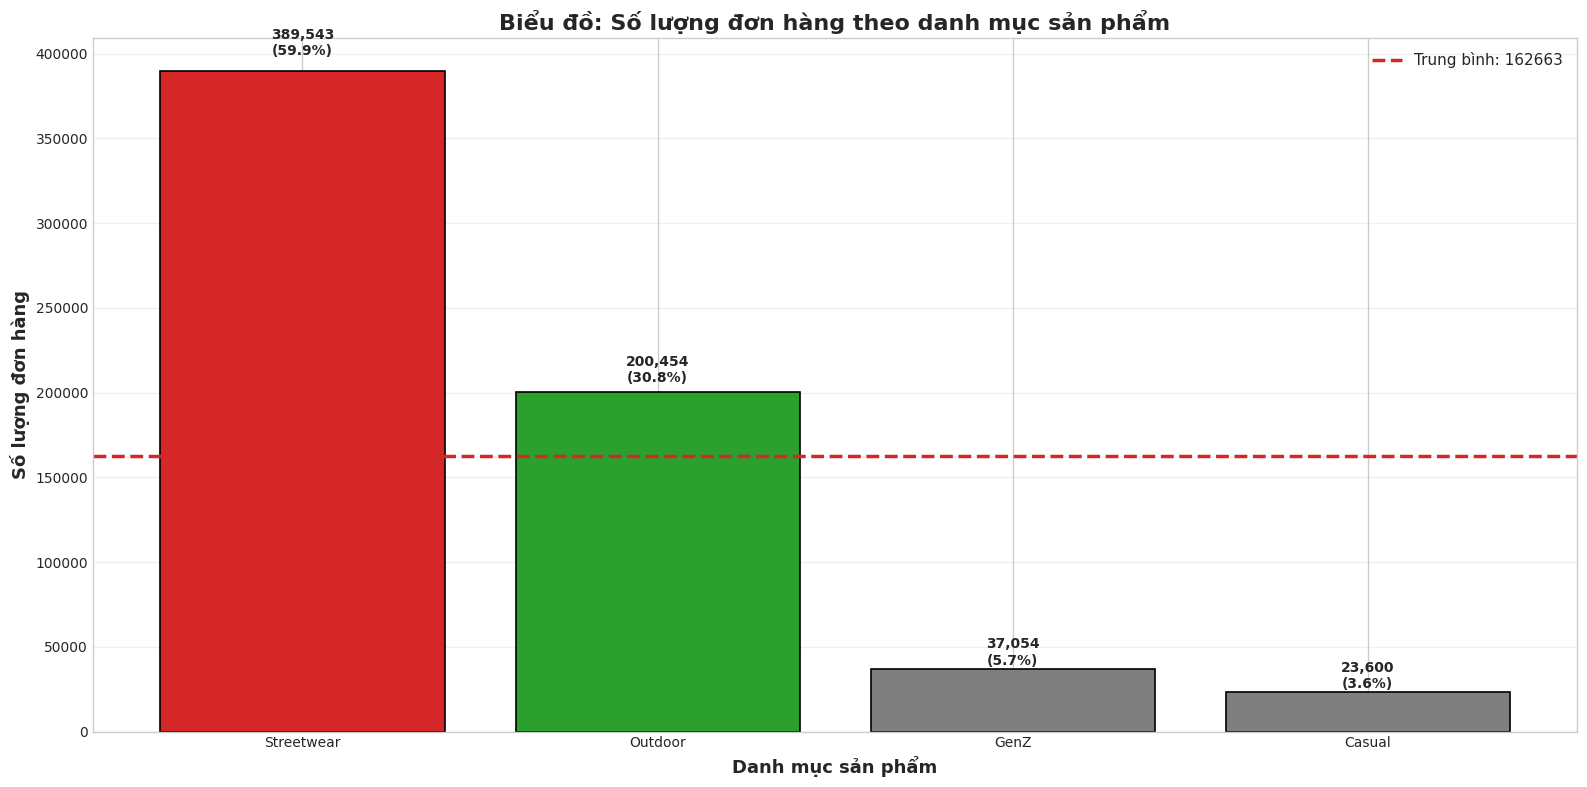


BIỂU ĐỒ: SỐ LƯỢNG ĐƠN HÀNG THEO DANH MỤC SẢN PHẨM
Streetwear: 389,543 đơn (59.9%) - ▲ Cao hơn TB
Outdoor: 200,454 đơn (30.8%) - ▲ Cao hơn TB
GenZ: 37,054 đơn (5.7%) - ▼ Thấp hơn TB
Casual: 23,600 đơn (3.6%) - ▼ Thấp hơn TB
Trung bình: 162663 đơn


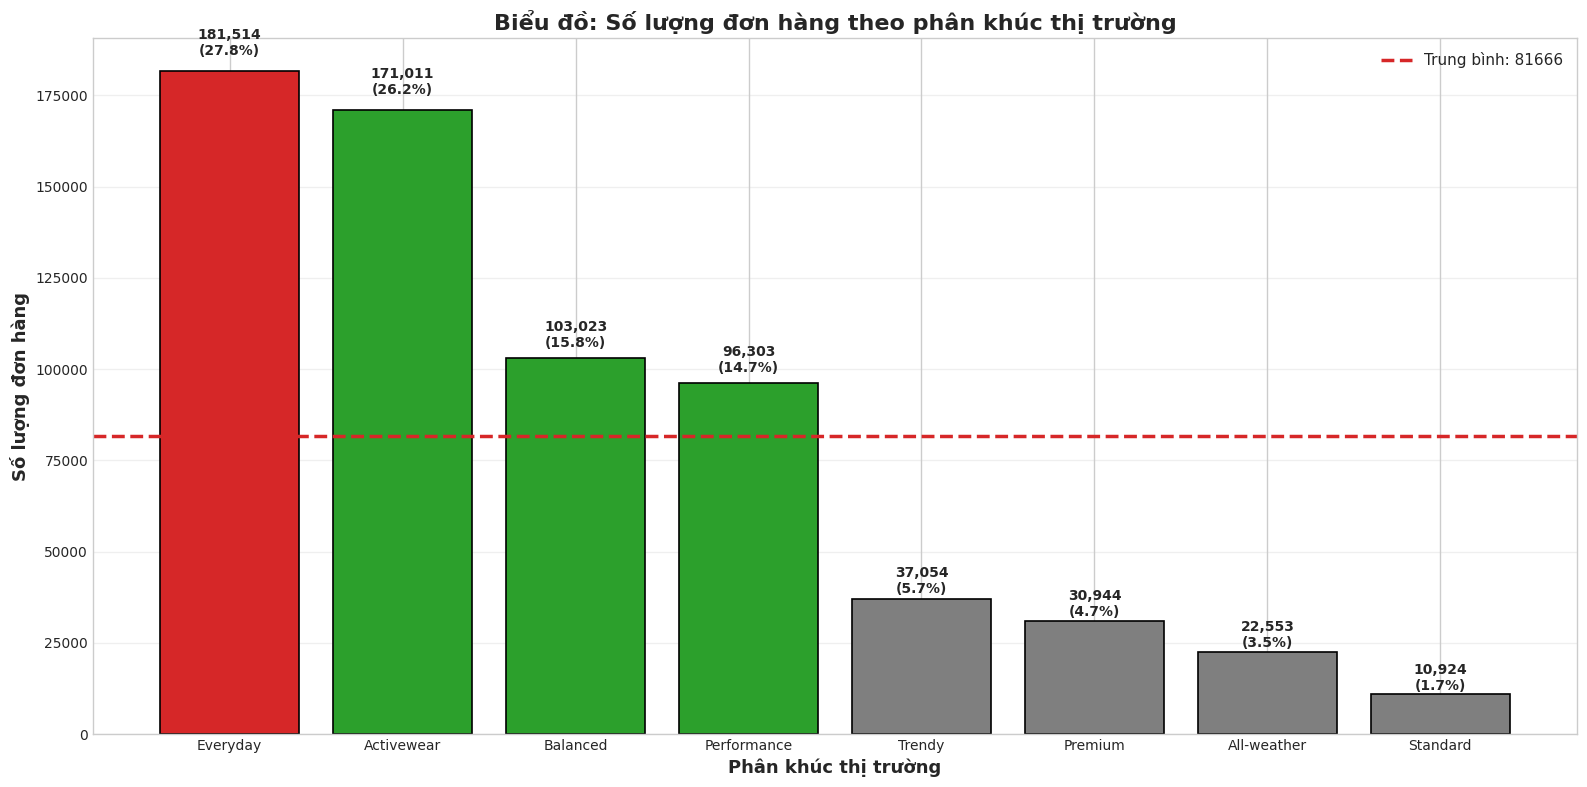


BIỂU ĐỒ: SỐ LƯỢNG ĐƠN HÀNG THEO PHÂN KHÚC THỊ TRƯỜNG
Everyday: 181,514 đơn (27.8%) - ▲ Cao hơn TB
Activewear: 171,011 đơn (26.2%) - ▲ Cao hơn TB
Balanced: 103,023 đơn (15.8%) - ▲ Cao hơn TB
Performance: 96,303 đơn (14.7%) - ▲ Cao hơn TB
Trendy: 37,054 đơn (5.7%) - ▼ Thấp hơn TB
Premium: 30,944 đơn (4.7%) - ▼ Thấp hơn TB
All-weather: 22,553 đơn (3.5%) - ▼ Thấp hơn TB
Standard: 10,924 đơn (1.7%) - ▼ Thấp hơn TB
Trung bình: 81666 đơn


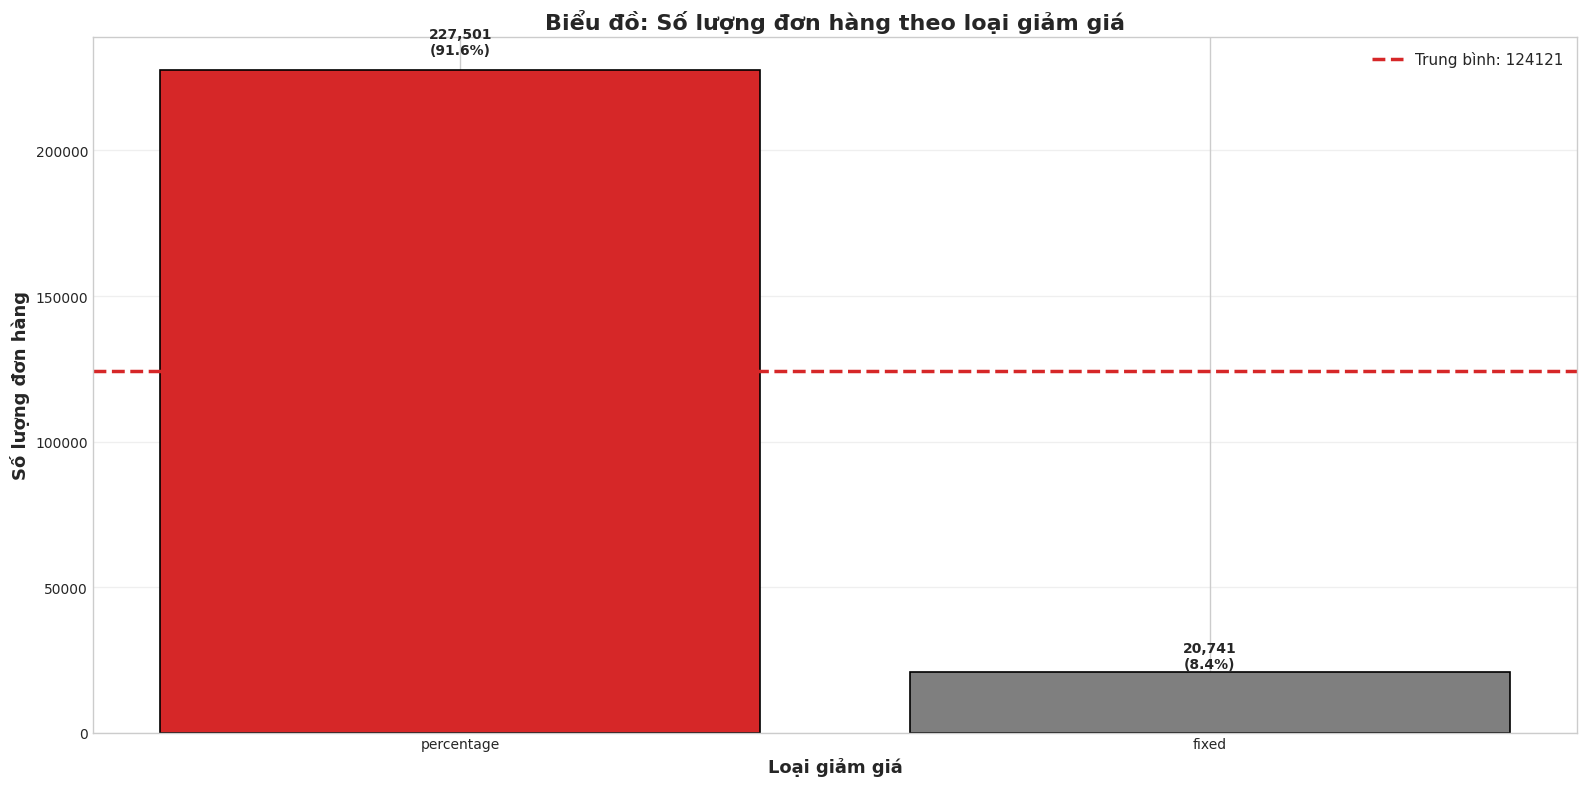


BIỂU ĐỒ: SỐ LƯỢNG ĐƠN HÀNG THEO LOẠI GIẢM GIÁ
percentage: 227,501 đơn (91.6%) - ▲ Cao hơn TB
fixed: 20,741 đơn (8.4%) - ▼ Thấp hơn TB
Trung bình: 124121 đơn


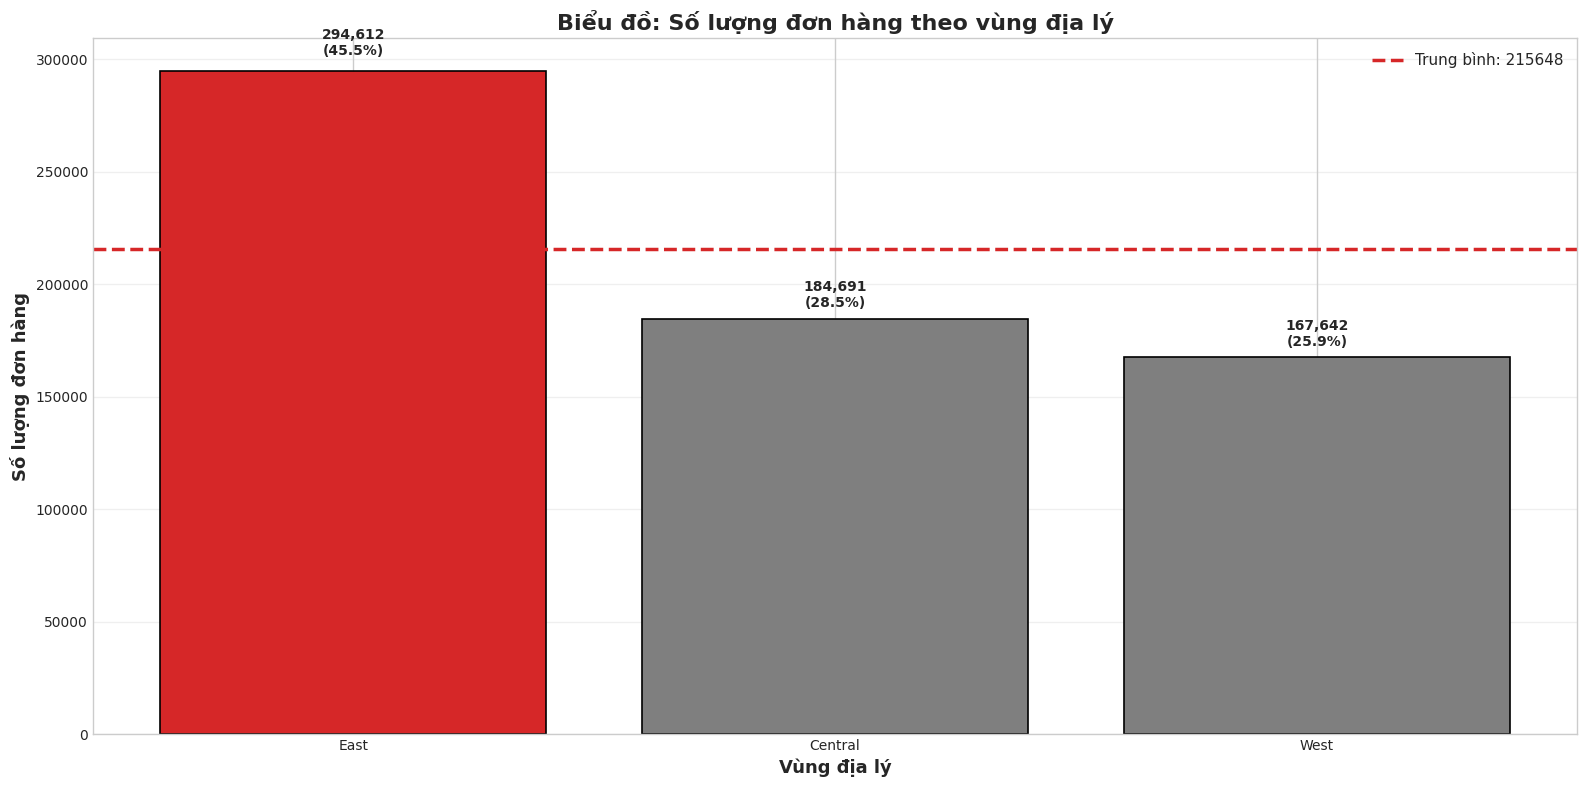


BIỂU ĐỒ: SỐ LƯỢNG ĐƠN HÀNG THEO VÙNG ĐỊA LÝ
East: 294,612 đơn (45.5%) - ▲ Cao hơn TB
Central: 184,691 đơn (28.5%) - ▼ Thấp hơn TB
West: 167,642 đơn (25.9%) - ▼ Thấp hơn TB
Trung bình: 215648 đơn


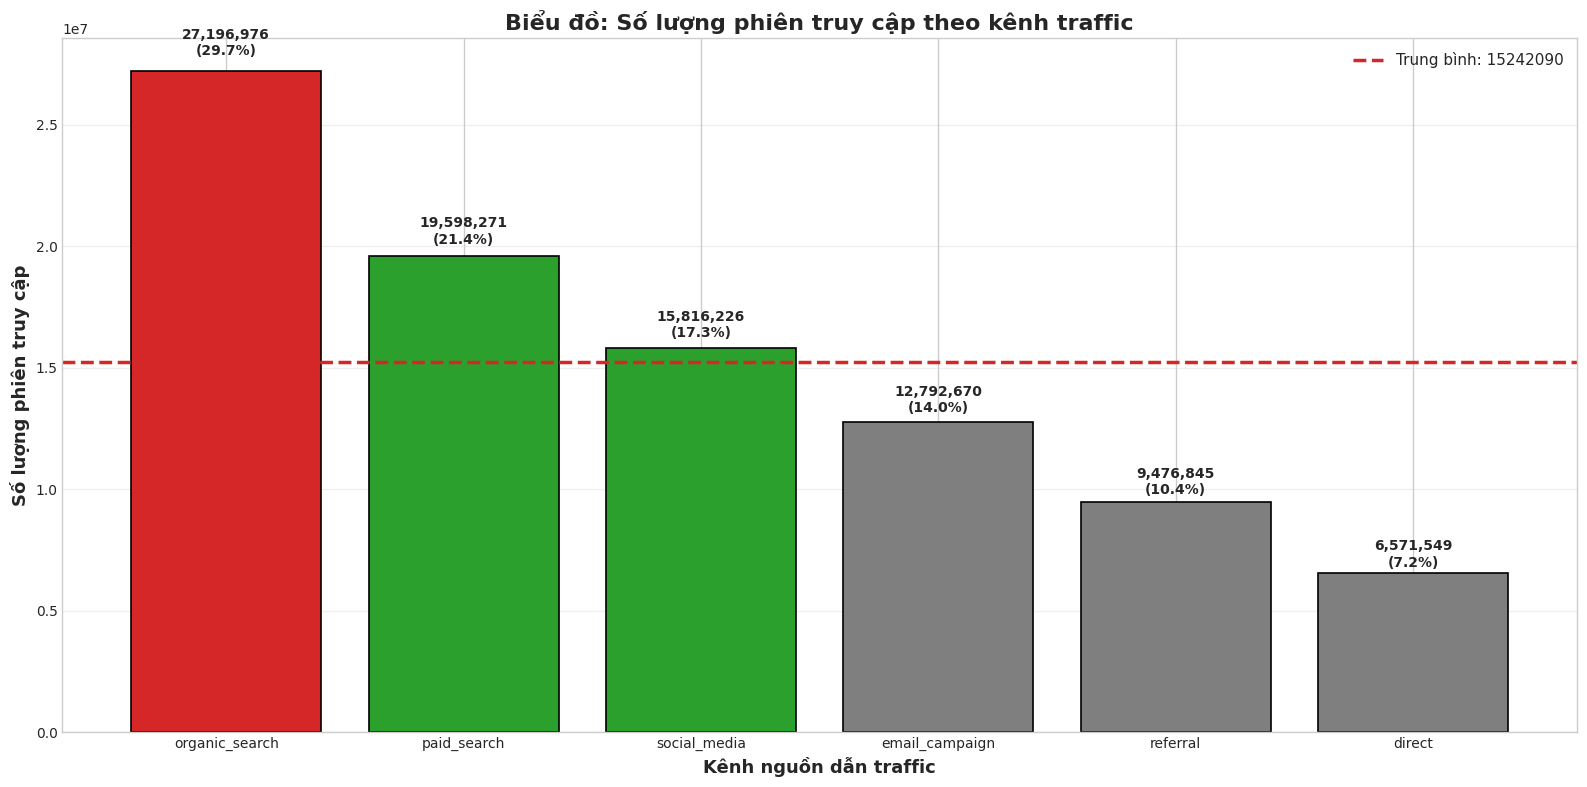


BIỂU ĐỒ: SỐ LƯỢNG PHIÊN TRUY CẬP THEO KÊNH TRAFFIC
organic_search: 27,196,976 đơn (29.7%) - ▲ Cao hơn TB
paid_search: 19,598,271 đơn (21.4%) - ▲ Cao hơn TB
social_media: 15,816,226 đơn (17.3%) - ▲ Cao hơn TB
email_campaign: 12,792,670 đơn (14.0%) - ▼ Thấp hơn TB
referral: 9,476,845 đơn (10.4%) - ▼ Thấp hơn TB
direct: 6,571,549 đơn (7.2%) - ▼ Thấp hơn TB
Trung bình: 15242090 đơn


In [ ]:
# ============================================
# 5 BIỂU ĐỒ SỐ LƯỢNG ĐƠN HÀNG
# ============================================

# Chuẩn bị dữ liệu cơ bản
data['orders']['order_date'] = pd.to_datetime(data['orders']['order_date'])

# ============================================
# BIỂU ĐỒ 1: THEO DANH MỤC SẢN PHẨM
# ============================================
products_cat = data['products'][['product_id', 'category']]
order_items_cat = data['order_items'].merge(products_cat, on='product_id', how='left')
order_count_cat = order_items_cat.groupby('category')['order_id'].nunique().sort_values(ascending=False)
order_count_cat_pct = (order_count_cat / order_count_cat.sum()) * 100
avg_cat = order_count_cat.mean()

# ============================================
# BIỂU ĐỒ 2: THEO PHÂN KHÚC THỊ TRƯỜNG
# ============================================
products_seg = data['products'][['product_id', 'segment']]
order_items_seg = data['order_items'].merge(products_seg, on='product_id', how='left')
order_count_seg = order_items_seg.groupby('segment')['order_id'].nunique().sort_values(ascending=False)
order_count_seg_pct = (order_count_seg / order_count_seg.sum()) * 100
avg_seg = order_count_seg.mean()

# ============================================
# BIỂU ĐỒ 3: THEO LOẠI GIẢM GIÁ (từ promotions)
# ============================================
# Lấy thông tin loại giảm giá từ promotions
promo_type = data['promotions'][['promo_id', 'promo_type']]
order_items_promo = data['order_items'].merge(promo_type, left_on='promo_id', right_on='promo_id', how='left')
# Chỉ lấy các đơn có áp dụng khuyến mãi
order_items_promo = order_items_promo[order_items_promo['promo_type'].notna()]
order_count_promo = order_items_promo.groupby('promo_type')['order_id'].nunique().sort_values(ascending=False)
order_count_promo_pct = (order_count_promo / order_count_promo.sum()) * 100
avg_promo = order_count_promo.mean() if len(order_count_promo) > 0 else 0

# ============================================
# BIỂU ĐỒ 4: THEO VÙNG ĐỊA LÝ
# ============================================
geo_region = data['geography'][['zip', 'region']]
orders_region = data['orders'].merge(geo_region, on='zip', how='left')
order_count_region = orders_region.groupby('region')['order_id'].nunique().sort_values(ascending=False)
order_count_region_pct = (order_count_region / order_count_region.sum()) * 100
avg_region = order_count_region.mean()

# ============================================
# BIỂU ĐỒ 5: THEO KÊNH TRAFFIC (từ web_traffic)
# ============================================
# Sử dụng web_traffic để biết số phiên theo từng nguồn
traffic_by_source = data['web_traffic'].groupby('traffic_source')['sessions'].sum().sort_values(ascending=False)
traffic_by_source_pct = (traffic_by_source / traffic_by_source.sum()) * 100
avg_traffic = traffic_by_source.mean()

# ============================================
# HÀM VẼ BIỂU ĐỒ (DÙNG CHUNG)
# ============================================
def ve_bieu_do(data_series, data_pct, avg_value, title, xlabel, ylabel='Số lượng đơn hàng'):
    fig, ax = plt.subplots(figsize=(16, 8))

    # Xác định màu sắc
    colors = []
    max_val = data_series.max()
    for val in data_series.values:
        if val == max_val:
            colors.append(COLOR_HIGHLIGHT)      # Cao nhất: đỏ
        elif val > avg_value:
            colors.append(COLOR_SUCCESS)   # Trên TB: xanh lá
        else:
            colors.append(COLOR_NEUTRAL)    # Dưới TB: xám

    bars = ax.bar(data_series.index, data_series.values, color=colors, edgecolor='black', linewidth=1.2)

    # Đường trung bình
    ax.axhline(y=avg_value, color=COLOR_HIGHLIGHT, linestyle='--', linewidth=2.5,
               label=f'Trung bình: {avg_value:.0f}')

    ax.set_xlabel(xlabel, fontsize=13, fontweight='bold')
    ax.set_ylabel(ylabel, fontsize=13, fontweight='bold')
    ax.set_title(title, fontsize=16, fontweight='bold')
    ax.grid(True, alpha=0.3, axis='y')
    ax.legend(loc='upper right', fontsize=11)
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=0, ha='center')

    # Thêm nhãn số liệu
    for bar, val, pct in zip(bars, data_series.values, data_pct):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(5, bar.get_height()*0.02),
                f'{val:,.0f}\n({pct:.1f}%)', ha='center', va='bottom', fontsize=10, fontweight='bold')

    plt.tight_layout()
    plt.show()

    # In thống kê
    print("\n" + "="*70)
    print(title.upper())
    print("="*70)
    for name, val, pct in zip(data_series.index, data_series.values, data_pct):
        status = "▲ Cao hơn TB" if val > avg_value else "▼ Thấp hơn TB" if val < avg_value else "● Bằng TB"
        print(f"{name}: {val:,.0f} đơn ({pct:.1f}%) - {status}")
    print(f"Trung bình: {avg_value:.0f} đơn")
    print("="*70)

# ============================================
# VẼ 5 BIỂU ĐỒ
# ============================================

# Biểu đồ 1: Theo danh mục sản phẩm
ve_bieu_do(
    order_count_cat, order_count_cat_pct, avg_cat,
    "Biểu đồ: Số lượng đơn hàng theo danh mục sản phẩm",
    "Danh mục sản phẩm"
)

# Biểu đồ 2: Theo phân khúc thị trường
ve_bieu_do(
    order_count_seg, order_count_seg_pct, avg_seg,
    "Biểu đồ: Số lượng đơn hàng theo phân khúc thị trường",
    "Phân khúc thị trường"
)

# Biểu đồ 3: Theo loại giảm giá
if len(order_count_promo) > 0:
    ve_bieu_do(
        order_count_promo, order_count_promo_pct, avg_promo,
        "Biểu đồ: Số lượng đơn hàng theo loại giảm giá",
        "Loại giảm giá"
    )
else:
    print("Không có dữ liệu khuyến mãi để vẽ biểu đồ 3")

# Biểu đồ 4: Theo vùng địa lý
ve_bieu_do(
    order_count_region, order_count_region_pct, avg_region,
    "Biểu đồ: Số lượng đơn hàng theo vùng địa lý",
    "Vùng địa lý"
)

# Biểu đồ 5: Theo kênh nguồn dẫn traffic
ve_bieu_do(
    traffic_by_source, traffic_by_source_pct, avg_traffic,
    "Biểu đồ: Số lượng phiên truy cập theo kênh traffic",
    "Kênh nguồn dẫn traffic",
    ylabel="Số lượng phiên truy cập"
)

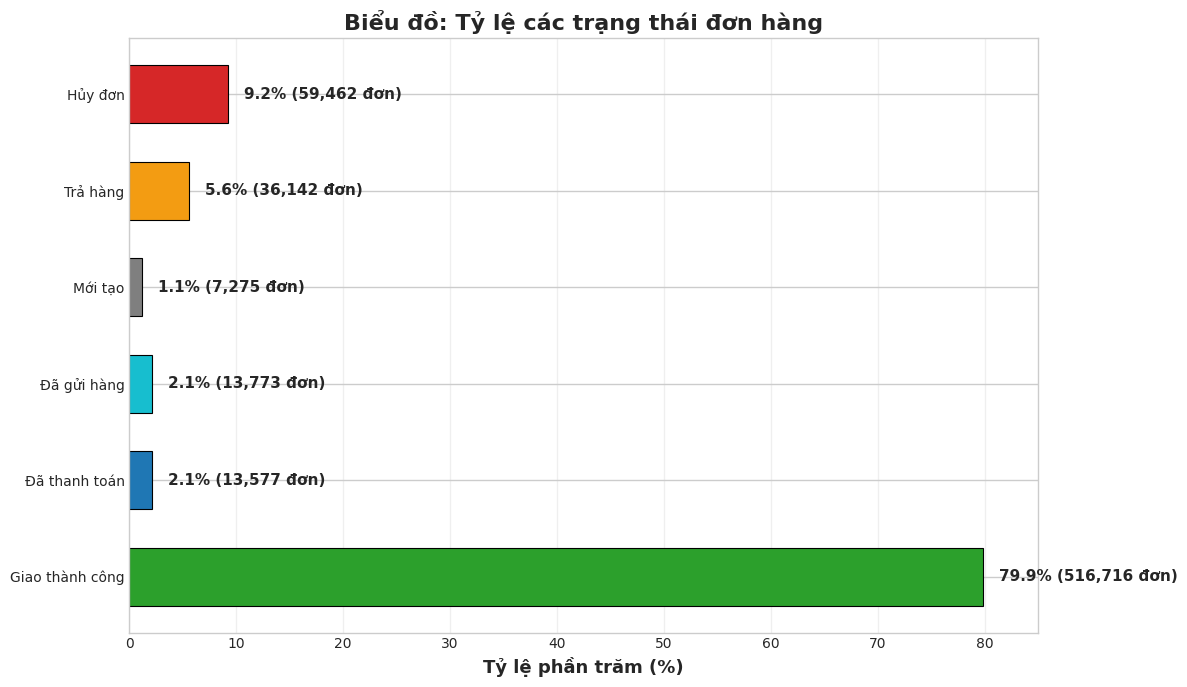


THỐNG KÊ TRẠNG THÁI ĐƠN HÀNG
Giao thành công: 516,716 đơn (79.9%)
Đã thanh toán: 13,577 đơn (2.1%)
Đã gửi hàng: 13,773 đơn (2.1%)
Mới tạo: 7,275 đơn (1.1%)
Trả hàng: 36,142 đơn (5.6%)
Hủy đơn: 59,462 đơn (9.2%)
----------------------------------------
TỔNG SỐ ĐƠN HÀNG: 646,945
Tỷ lệ đơn thành công: 79.9%
Tỷ lệ đơn thất bại: 14.8%


In [ ]:
# ============================================
# BIỂU ĐỒ 2: TRẠNG THÁI ĐƠN HÀNG (CHỈ THANH NGANG)
# ============================================

# Lấy số lượng theo từng trạng thái
status_counts = data['orders']['order_status'].value_counts()

# Sắp xếp theo thứ tự từ tốt đến xấu (từ trên xuống dưới)
thu_tu_trang_thai = ['delivered', 'paid', 'shipped', 'created', 'returned', 'cancelled']
status_counts = status_counts.reindex(thu_tu_trang_thai)

# Tên hiển thị bằng tiếng Việt
ten_tieng_viet = {
    'delivered': 'Giao thành công',
    'paid': 'Đã thanh toán',
    'shipped': 'Đã gửi hàng',
    'created': 'Mới tạo',
    'returned': 'Trả hàng',
    'cancelled': 'Hủy đơn'
}

# Màu sắc hoàn toàn riêng biệt cho từng trạng thái
mau_sac = {
    'delivered': '#2ca02c',   # xanh lá - thành công
    'paid': '#1f77b4',        # xanh dương - đã thanh toán
    'shipped': '#17becf',     # xanh ngọc - đã gửi
    'created': '#7f7f7f',     # xám - chưa xử lý
    'returned': '#f39c12',    # cam - trả hàng
    'cancelled': '#d62728'    # đỏ - hủy bỏ
}

# Lấy danh sách theo đúng thứ tự
ds_nhan = [ten_tieng_viet[status] for status in status_counts.index]
ds_mau = [mau_sac[status] for status in status_counts.index]
ti_le = (status_counts.values / status_counts.sum()) * 100

# Tạo figure
fig, ax = plt.subplots(figsize=(12, 7))

# Vẽ thanh ngang
bars = ax.barh(ds_nhan, ti_le, color=ds_mau, edgecolor='black', linewidth=0.8, height=0.6)

# Tiêu đề và nhãn
ax.set_xlabel('Tỷ lệ phần trăm (%)', fontsize=13, fontweight='bold')
ax.set_title('Biểu đồ: Tỷ lệ các trạng thái đơn hàng', fontsize=16, fontweight='bold')
ax.set_xlim(0, 85)
ax.grid(True, alpha=0.3, axis='x')
ax.set_axisbelow(True)

# Thêm nhãn số liệu vào cuối mỗi thanh
for i, (tile, status) in enumerate(zip(ti_le, status_counts.index)):
    so_luong = status_counts[status]
    ax.text(tile + 1.5, i, f'{tile:.1f}% ({so_luong:,} đơn)',
            va='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

# In thống kê
print("\n" + "="*60)
print("THỐNG KÊ TRẠNG THÁI ĐƠN HÀNG")
print("="*60)
for status, count in status_counts.items():
    tile = count / status_counts.sum() * 100
    print(f"{ten_tieng_viet[status]}: {count:,} đơn ({tile:.1f}%)")
print("-"*40)
print(f"TỔNG SỐ ĐƠN HÀNG: {status_counts.sum():,}")
print(f"Tỷ lệ đơn thành công: {status_counts['delivered']/status_counts.sum()*100:.1f}%")
print(f"Tỷ lệ đơn thất bại: {(status_counts['cancelled'] + status_counts['returned'])/status_counts.sum()*100:.1f}%")
print("="*60)

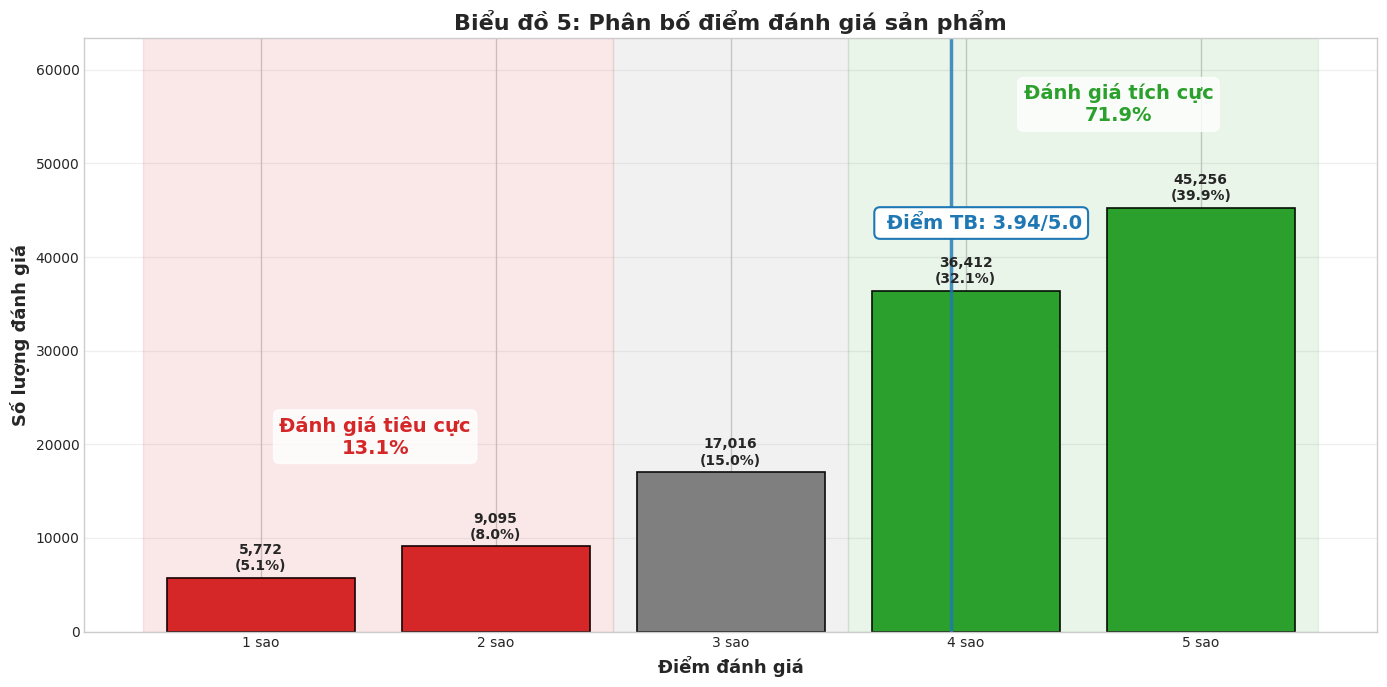


THỐNG KÊ ĐÁNH GIÁ SẢN PHẨM
Điểm trung bình: 3.94 / 5.0
Tổng số đánh giá: 113,551
----------------------------------------
Vùng tiêu cực (1-2 sao): 14,867 đánh giá (13.1%)
Vùng trung bình (3 sao): 17,016 đánh giá (15.0%)
Vùng tích cực (4-5 sao): 81,668 đánh giá (71.9%)


In [ ]:
# ============================================
# BIỂU ĐỒ 5: PHÂN BỐ ĐÁNH GIÁ SẢN PHẨM (3 VÙNG RÕ RÀNG)
# ============================================

# Lấy dữ liệu đánh giá
ratings = data['reviews']['rating'].value_counts().sort_index()

# Tạo mapping đúng thứ tự từ 1 đến 5
rating_counts = {i: ratings.get(i, 0) for i in range(1, 6)}
rating_values = list(rating_counts.values())
rating_labels = ['1 sao', '2 sao', '3 sao', '4 sao', '5 sao']

# Tính tỷ lệ phần trăm
total_reviews = sum(rating_values)
rating_pct = [count / total_reviews * 100 for count in rating_values]

# Tính điểm trung bình
avg_rating = sum(rating * count for rating, count in rating_counts.items()) / total_reviews

# Nhóm theo vùng
tieu_cuc = rating_values[0] + rating_values[1]
tieu_cuc_pct = rating_pct[0] + rating_pct[1]
trung_binh = rating_values[2]
trung_binh_pct = rating_pct[2]
tich_cuc = rating_values[3] + rating_values[4]
tich_cuc_pct = rating_pct[3] + rating_pct[4]

# Tạo figure
fig, ax = plt.subplots(figsize=(14, 7))

# Màu sắc theo vùng
mau_sac = ['#d62728', '#d62728', '#7f7f7f', '#2ca02c', '#2ca02c']

bars = ax.bar(rating_labels, rating_values, color=mau_sac, edgecolor='black', linewidth=1.2)

# Vẽ các vùng nền trên trục Ox
ax.axvspan(-0.5, 1.5, alpha=0.1, color='#d62728', label='Vùng tiêu cực (1-2 sao)')
ax.axvspan(1.5, 2.5, alpha=0.1, color='#7f7f7f', label='Vùng trung bình (3 sao)')
ax.axvspan(2.5, 4.5, alpha=0.1, color='#2ca02c', label='Vùng tích cực (4-5 sao)')



# Tiêu đề và nhãn
ax.set_xlabel('Điểm đánh giá', fontsize=13, fontweight='bold')
ax.set_ylabel('Số lượng đánh giá', fontsize=13, fontweight='bold')
ax.set_title('Biểu đồ 5: Phân bố điểm đánh giá sản phẩm', fontsize=16, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')
ax.set_axisbelow(True)

# Thêm nhãn số liệu trên đầu mỗi cột
for bar, count, pct in zip(bars, rating_values, rating_pct):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500,
            f'{count:,}\n({pct:.1f}%)',
            ha='center', va='bottom', fontsize=10, fontweight='bold')

# Thêm chú thích phân nhóm đánh giá
ax.annotate('Đánh giá tiêu cực\n13.1%', xy=(0.225, 0.3), xycoords='axes fraction',
            fontsize=14, ha='center', color='#d62728', fontweight='bold',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
ax.annotate('Đánh giá tích cực\n71.9%', xy=(0.8, 0.86), xycoords='axes fraction',
            fontsize=14, ha='center', color='#2ca02c', fontweight='bold',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))



# Chuyển đổi điểm trung bình (3.94) thành vị trí trên trục x (từ 0 đến 4)
x_position = avg_rating - 1  # vì 1 sao ở vị trí 0, 2 sao ở 1, 3 sao ở 2, 4 sao ở 3, 5 sao ở 4
x_position_clamped = max(0, min(4, x_position))

# Vẽ đường thẳng đứng tại vị trí điểm trung bình
ax.axvline(x=x_position_clamped, color='#1f77b4', linestyle='-', linewidth=2.5, alpha=0.8)

# Thêm chú thích cho điểm trung bình
ax.text(x_position_clamped - 0.3, max(rating_values) * 0.95,
        f' Điểm TB: {avg_rating:.2f}/5.0',
        fontsize=14, fontweight='bold', color='#1f77b4',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='#1f77b4', linewidth=1.5))


# Điều chỉnh giới hạn trục y để có khoảng trống cho nhãn
ax.set_ylim(0, max(rating_values) * 1.4)

plt.tight_layout()
plt.show()

# In thống kê
print("\n" + "="*60)
print("THỐNG KÊ ĐÁNH GIÁ SẢN PHẨM")
print("="*60)
print(f"Điểm trung bình: {avg_rating:.2f} / 5.0")
print(f"Tổng số đánh giá: {total_reviews:,}")
print("-"*40)
print(f"Vùng tiêu cực (1-2 sao): {tieu_cuc:,} đánh giá ({tieu_cuc_pct:.1f}%)")
print(f"Vùng trung bình (3 sao): {trung_binh:,} đánh giá ({trung_binh_pct:.1f}%)")
print(f"Vùng tích cực (4-5 sao): {tich_cuc:,} đánh giá ({tich_cuc_pct:.1f}%)")
print("="*60)

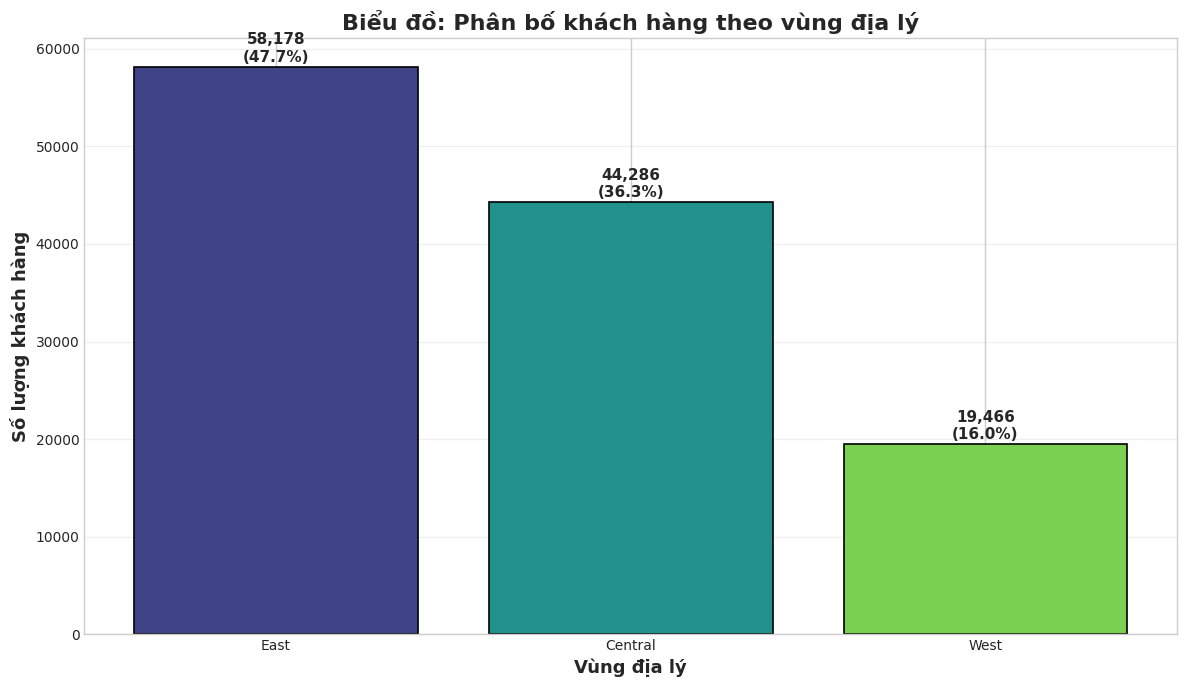


THỐNG KÊ KHÁCH HÀNG THEO VÙNG ĐỊA LÝ
East: 58,178 khách (47.7%)
Central: 44,286 khách (36.3%)
West: 19,466 khách (16.0%)
----------------------------------------
TỔNG SỐ KHÁCH HÀNG: 121,930
Vùng có nhiều khách nhất: East (58,178 khách, 47.7%)
Vùng có ít khách nhất: West (19,466 khách, 16.0%)


In [ ]:
# ============================================
# BIỂU ĐỒ: KHÁCH HÀNG THEO VÙNG ĐỊA LÝ
# ============================================

# Join customers với geography để lấy region
customer_region = data['customers'].merge(
    data['geography'][['zip', 'region']],
    on='zip',
    how='left'
)

# Đếm số lượng khách hàng theo vùng
region_counts = customer_region['region'].value_counts()

# Tính tỷ lệ phần trăm
region_pct = (region_counts / region_counts.sum()) * 100

# Tạo figure
fig, ax = plt.subplots(figsize=(12, 7))

# Màu sắc
colors = plt.cm.viridis(np.linspace(0.2, 0.8, len(region_counts)))

bars = ax.bar(region_counts.index, region_counts.values, color=colors, edgecolor='black', linewidth=1.2)

# Tiêu đề và nhãn
ax.set_xlabel('Vùng địa lý', fontsize=13, fontweight='bold')
ax.set_ylabel('Số lượng khách hàng', fontsize=13, fontweight='bold')
ax.set_title('Biểu đồ: Phân bố khách hàng theo vùng địa lý', fontsize=16, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')
ax.set_axisbelow(True)

# Thêm nhãn số liệu trên đầu mỗi cột
for bar, count, pct in zip(bars, region_counts.values, region_pct):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
            f'{count:,}\n({pct:.1f}%)',
            ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

# In thống kê
print("\n" + "="*60)
print("THỐNG KÊ KHÁCH HÀNG THEO VÙNG ĐỊA LÝ")
print("="*60)
for region, count, pct in zip(region_counts.index, region_counts.values, region_pct):
    print(f"{region}: {count:,} khách ({pct:.1f}%)")
print("-"*40)
print(f"TỔNG SỐ KHÁCH HÀNG: {region_counts.sum():,}")
print(f"Vùng có nhiều khách nhất: {region_counts.index[0]} ({region_counts.values[0]:,} khách, {region_pct.iloc[0]:.1f}%)")
print(f"Vùng có ít khách nhất: {region_counts.index[-1]} ({region_counts.values[-1]:,} khách, {region_pct.iloc[-1]:.1f}%)")
print("="*60)

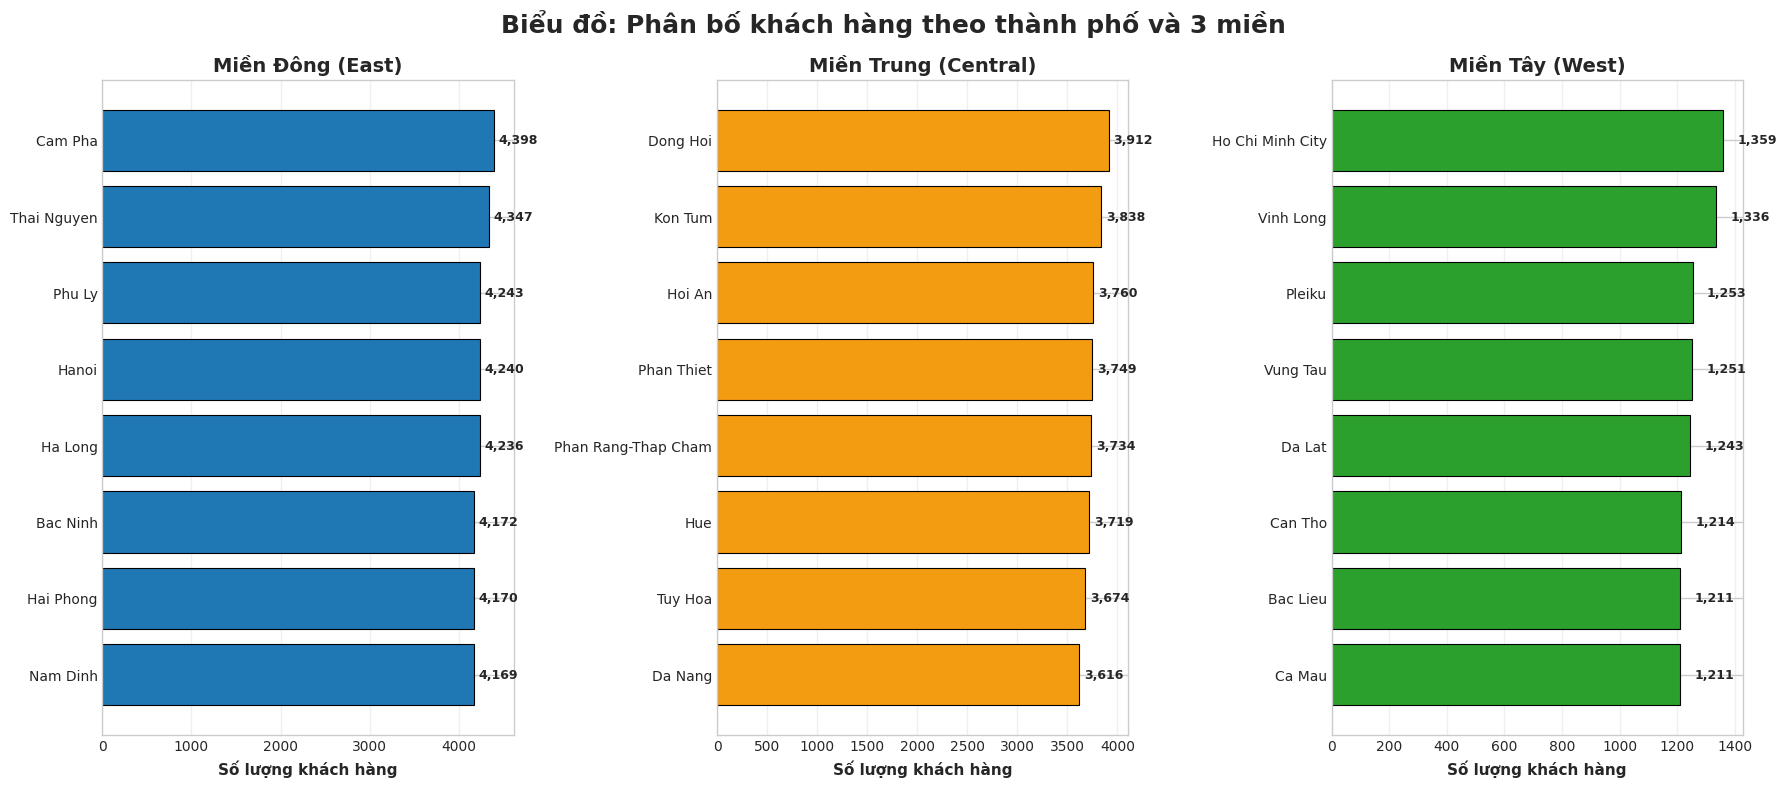


THỐNG KÊ PHÂN BỐ KHÁCH HÀNG THEO THÀNH PHỐ

📌 Miền Đông (East):
   Tổng khách hàng: 58,178
   - Cam Pha: 4,398 khách
   - Thai Nguyen: 4,347 khách
   - Phu Ly: 4,243 khách
   - Hanoi: 4,240 khách
   - Ha Long: 4,236 khách
   - Bac Ninh: 4,172 khách
   - Hai Phong: 4,170 khách
   - Nam Dinh: 4,169 khách
   - Bac Giang: 4,160 khách
   - Ninh Binh: 4,081 khách

📌 Miền Trung (Central):
   Tổng khách hàng: 44,286
   - Dong Hoi: 3,912 khách
   - Kon Tum: 3,838 khách
   - Hoi An: 3,760 khách
   - Phan Thiet: 3,749 khách
   - Phan Rang-Thap Cham: 3,734 khách
   - Hue: 3,719 khách
   - Tuy Hoa: 3,674 khách
   - Da Nang: 3,616 khách
   - Quang Ngai: 3,616 khách
   - Tam Ky: 3,562 khách

📌 Miền Tây (West):
   Tổng khách hàng: 19,466
   - Ho Chi Minh City: 1,359 khách
   - Vinh Long: 1,336 khách
   - Pleiku: 1,253 khách
   - Vung Tau: 1,251 khách
   - Da Lat: 1,243 khách
   - Can Tho: 1,214 khách
   - Bac Lieu: 1,211 khách
   - Ca Mau: 1,211 khách
   - Soc Trang: 1,208 khách
   - My Tho: 1,198 kh

In [ ]:
# ============================================
# BIỂU ĐỒ: PHÂN BỐ KHÁCH HÀNG THEO THÀNH PHỐ PHÂN THEO MIỀN
# ============================================

# Lấy thông tin khách hàng với địa lý
customer_geo = data['customers'].merge(
    data['geography'][['zip', 'city', 'region']],
    on='zip',
    how='left'
)

# Đếm số lượng khách hàng theo vùng và thành phố
city_customers = customer_geo.groupby(['region', 'city_y']).size().reset_index(name='customer_count')

# Sắp xếp giảm dần trong từng vùng
city_customers = city_customers.sort_values(['region', 'customer_count'], ascending=[True, False])

# Xác định thứ tự các vùng
thu_tu_vung = ['East', 'Central', 'West']

# Tên hiển thị
ten_hien_thi = {
    'East': 'Miền Đông (East)',
    'Central': 'Miền Trung (Central)',
    'West': 'Miền Tây (West)'
}

mau_sac_vung = {
    'East': '#1f77b4',   # xanh dương
    'Central': '#f39c12', # cam
    'West': '#2ca02c'     # xanh lá
}

# Tạo figure với 3 subplots
fig, axes = plt.subplots(1, 3, figsize=(18, 8))

for i, vung in enumerate(thu_tu_vung):
    ax = axes[i]
    data_vung = city_customers[city_customers['region'] == vung].head(8)

    if len(data_vung) > 0:
        bars = ax.barh(range(len(data_vung)), data_vung['customer_count'].values,
                       color=mau_sac_vung.get(vung, '#7f7f7f'), edgecolor='black', linewidth=0.8)
        ax.set_yticks(range(len(data_vung)))
        ax.set_yticklabels(data_vung['city_y'].values, fontsize=10)
        ax.set_xlabel('Số lượng khách hàng', fontsize=11, fontweight='bold')
        ax.set_title(ten_hien_thi.get(vung, vung), fontsize=14, fontweight='bold')
        ax.invert_yaxis()
        ax.grid(True, alpha=0.3, axis='x')

        # Thêm nhãn số liệu
        for bar, count in zip(bars, data_vung['customer_count'].values):
            ax.text(bar.get_width() + 50, bar.get_y() + bar.get_height()/2,
                   f'{count:,}', va='center', fontsize=9, fontweight='bold')
    else:
        ax.text(0.5, 0.5, 'Không có dữ liệu', transform=ax.transAxes,
               ha='center', va='center', fontsize=12)
        ax.set_title(ten_hien_thi.get(vung, vung), fontsize=14, fontweight='bold')
        ax.set_xlabel('Số lượng khách hàng', fontsize=11, fontweight='bold')

plt.suptitle('Biểu đồ: Phân bố khách hàng theo thành phố và 3 miền', fontsize=18, fontweight='bold')
plt.tight_layout()
plt.show()

# In thống kê chi tiết
print("\n" + "="*80)
print("THỐNG KÊ PHÂN BỐ KHÁCH HÀNG THEO THÀNH PHỐ")
print("="*80)
for vung in thu_tu_vung:
    print(f"\n📌 {ten_hien_thi.get(vung, vung)}:")
    data_vung = city_customers[city_customers['region'] == vung].head(10)
    tong_khach = data_vung['customer_count'].sum()
    tong_vung = customer_geo[customer_geo['region'] == vung].shape[0]
    print(f"   Tổng khách hàng: {tong_vung:,}")
    for _, row in data_vung.iterrows():
        print(f"   - {row['city_y']}: {row['customer_count']:,} khách")
print("="*80)

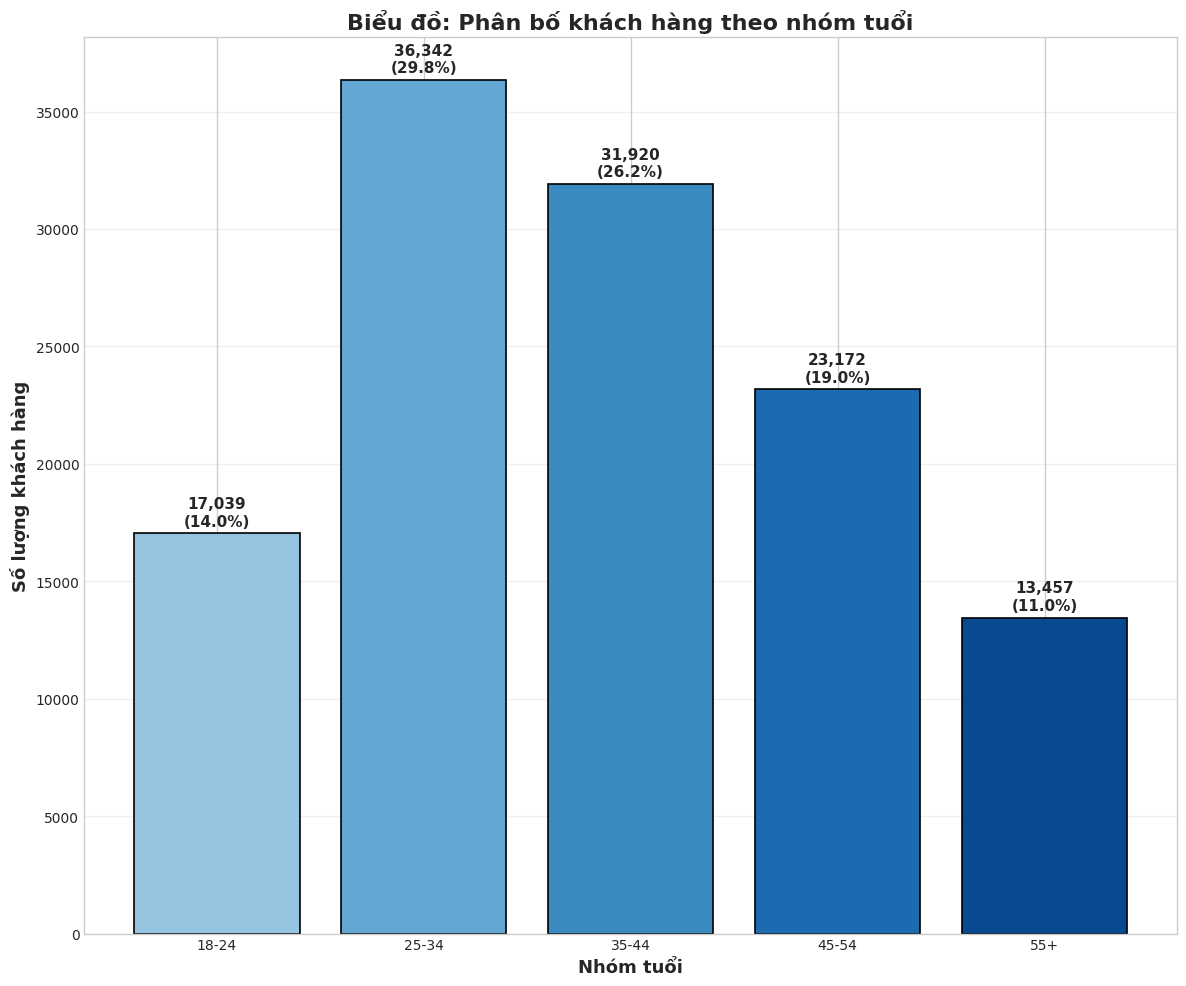


THỐNG KÊ KHÁCH HÀNG THEO NHÓM TUỔI
18-24: 17,039 khách (14.0%)
25-34: 36,342 khách (29.8%)
35-44: 31,920 khách (26.2%)
45-54: 23,172 khách (19.0%)
55+: 13,457 khách (11.0%)
----------------------------------------
TỔNG SỐ KHÁCH CÓ THÔNG TIN TUỔI: 121,930
Nhóm tuổi đông nhất: 18-24 (17,039 khách, 14.0%)


In [ ]:
# ============================================
# BIỂU ĐỒ: KHÁCH HÀNG THEO NHÓM TUỔI
# ============================================

# Lấy dữ liệu nhóm tuổi, bỏ qua null
age_data = data['customers'][data['customers']['age_group'].notna()]

# Đếm số lượng khách hàng theo nhóm tuổi
age_counts = age_data['age_group'].value_counts()

# Sắp xếp theo thứ tự tuổi tăng dần
thu_tu_tuoi = ['18-24', '25-34', '35-44', '45-54', '55+']
age_counts = age_counts.reindex(thu_tu_tuoi)

# Tính tỷ lệ phần trăm
age_pct = (age_counts / age_counts.sum()) * 100

# Tạo figure
fig, ax = plt.subplots(figsize=(12,10))

# Màu sắc
colors = plt.cm.Blues(np.linspace(0.4, 0.9, len(age_counts)))

bars = ax.bar(age_counts.index, age_counts.values, color=colors, edgecolor='black', linewidth=1.2)

# Tiêu đề và nhãn
ax.set_xlabel('Nhóm tuổi', fontsize=13, fontweight='bold')
ax.set_ylabel('Số lượng khách hàng', fontsize=13, fontweight='bold')
ax.set_title('Biểu đồ: Phân bố khách hàng theo nhóm tuổi', fontsize=16, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')
ax.set_axisbelow(True)

# Thêm nhãn số liệu trên đầu mỗi cột
for bar, count, pct in zip(bars, age_counts.values, age_pct):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
            f'{count:,}\n({pct:.1f}%)',
            ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

# In thống kê
print("\n" + "="*60)
print("THỐNG KÊ KHÁCH HÀNG THEO NHÓM TUỔI")
print("="*60)
for age, count, pct in zip(age_counts.index, age_counts.values, age_pct):
    print(f"{age}: {count:,} khách ({pct:.1f}%)")
print("-"*40)
print(f"TỔNG SỐ KHÁCH CÓ THÔNG TIN TUỔI: {age_counts.sum():,}")
print(f"Nhóm tuổi đông nhất: {age_counts.index[0]} ({age_counts.values[0]:,} khách, {age_pct.iloc[0]:.1f}%)")
print("="*60)

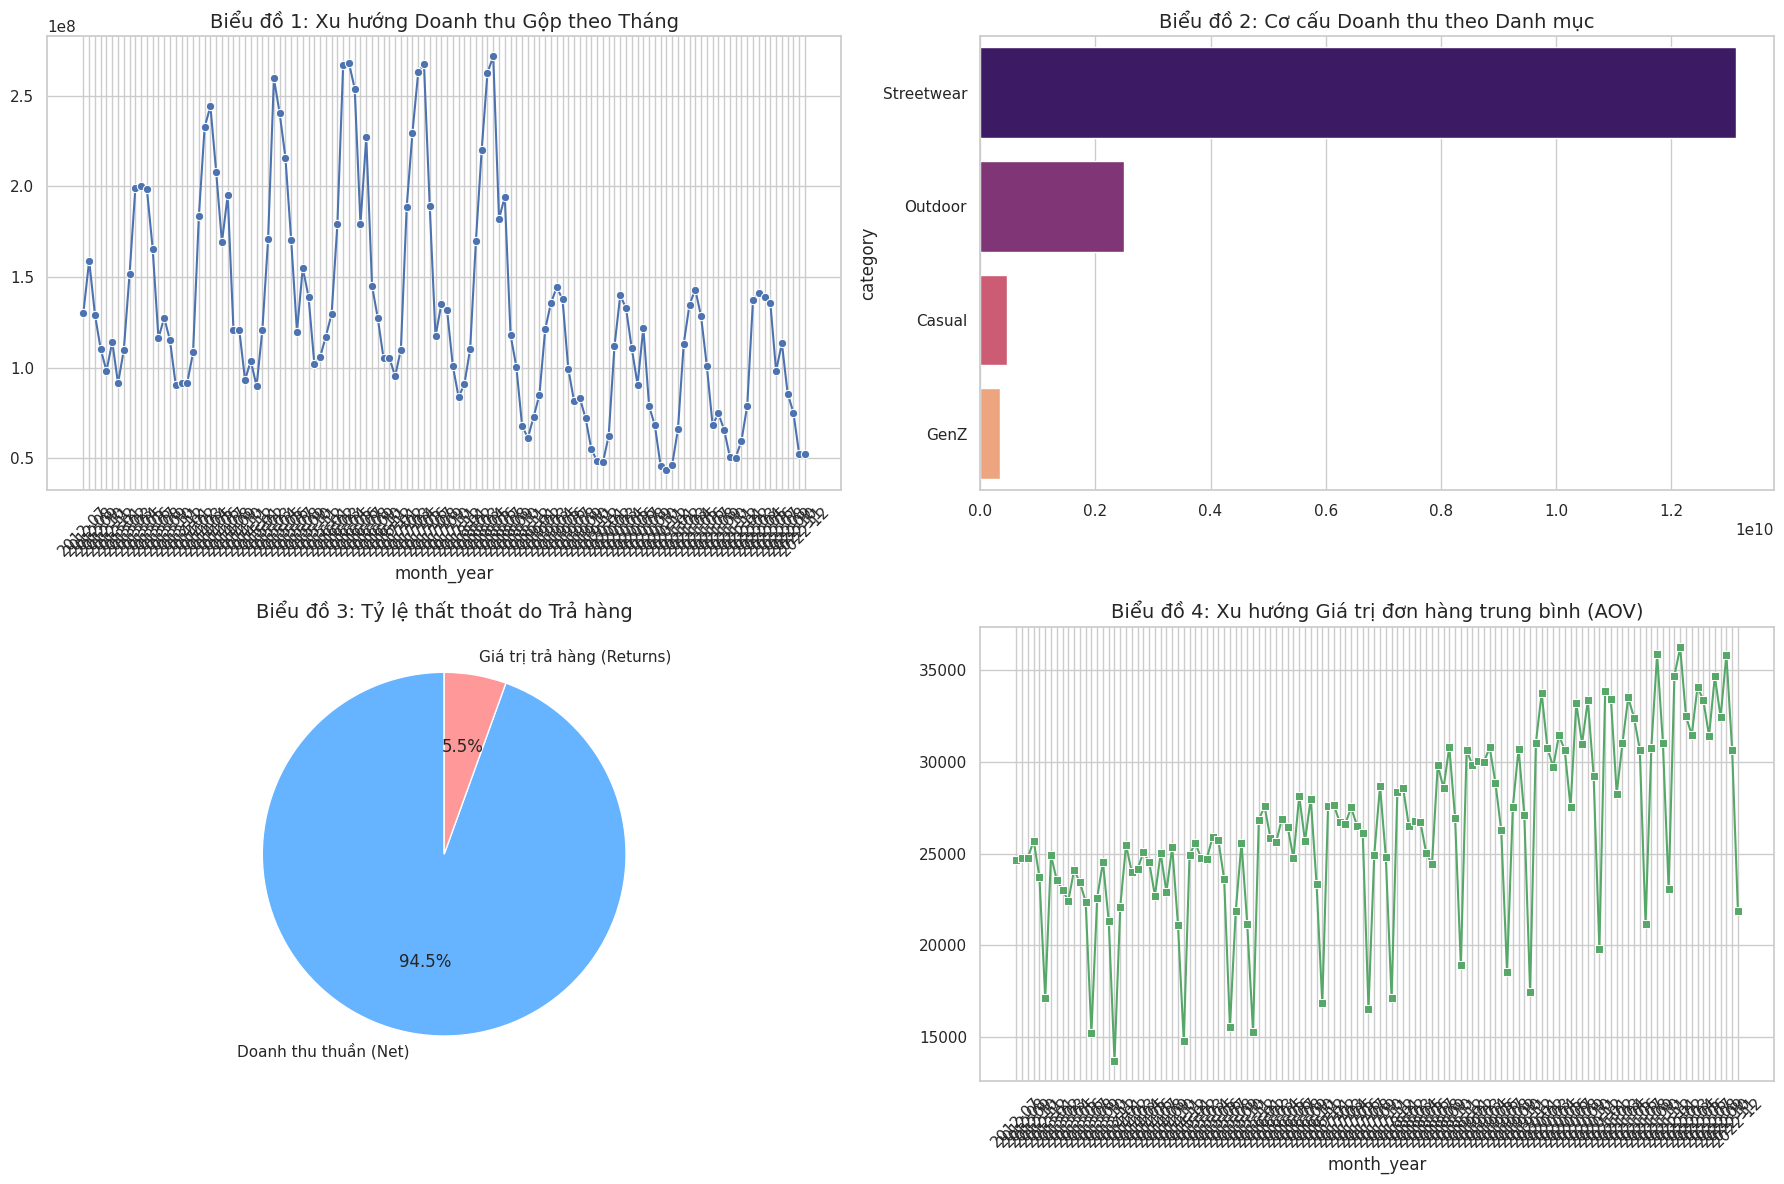

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Chuẩn bị dữ liệu trên bản copy
df_items = data['order_items'].copy()
df_orders = data['orders'].copy()
df_prods = data['products'].copy()
df_returns = data['returns'].copy()

# Tính toán doanh thu gộp
df_items['gross_revenue'] = df_items['quantity'] * df_items['unit_price']

# Gộp bảng để có thông tin thời gian và danh mục
df_master = df_items.merge(df_prods[['product_id', 'category']], on='product_id', how='left')
df_master = df_master.merge(df_orders[['order_id', 'order_date']], on='order_id', how='left')
df_master['order_date'] = pd.to_datetime(df_master['order_date'])
df_master['month_year'] = df_master['order_date'].dt.to_period('M').astype(str)

# thiết lập phong cách vẽ
sns.set(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# --- BIỂU ĐỒ 1: Xu hướng Doanh thu theo tháng ---
monthly_rev = df_master.groupby('month_year')['gross_revenue'].sum()
sns.lineplot(x=monthly_rev.index, y=monthly_rev.values, marker='o', ax=axes[0, 0], color='b')
axes[0, 0].set_title('Biểu đồ 1: Xu hướng Doanh thu Gộp theo Tháng', fontsize=14)
axes[0, 0].tick_params(axis='x', rotation=45)

# --- BIỂU ĐỒ 2: Doanh thu theo Danh mục Sản phẩm ---
rev_by_cat = df_master.groupby('category')['gross_revenue'].sum().sort_values(ascending=False)
sns.barplot(x=rev_by_cat.values, y=rev_by_cat.index, palette='magma', ax=axes[0, 1])
axes[0, 1].set_title('Biểu đồ 2: Cơ cấu Doanh thu theo Danh mục', fontsize=14)

# --- BIỂU ĐỒ 3: So sánh Gross vs Net Revenue (Tác động của trả hàng) ---
# Tính giá trị hàng trả lại
df_ret_val = df_returns.merge(df_items[['order_id', 'product_id', 'quantity', 'unit_price']], on=['order_id', 'product_id'], how='left')
df_ret_val['return_value'] = df_ret_val['quantity'] * df_ret_val['unit_price']
total_return_val = df_ret_val['return_value'].sum()
total_gross_val = df_master['gross_revenue'].sum()

axes[1, 0].pie([total_gross_val - total_return_val, total_return_val],
                labels=['Doanh thu thuần (Net)', 'Giá trị trả hàng (Returns)'],
                autopct='%1.1f%%', colors=['#66b3ff','#ff9999'], startangle=90)
axes[1, 0].set_title('Biểu đồ 3: Tỷ lệ thất thoát do Trả hàng', fontsize=14)

# --- BIỂU ĐỒ 4: Giá trị đơn hàng trung bình (AOV) theo tháng ---
order_counts = df_orders.groupby(df_orders['order_date'].dt.to_period('M'))['order_id'].nunique()
aov_monthly = monthly_rev.values / order_counts.values
sns.lineplot(x=monthly_rev.index, y=aov_monthly, marker='s', ax=axes[1, 1], color='g')
axes[1, 1].set_title('Biểu đồ 4: Xu hướng Giá trị đơn hàng trung bình (AOV)', fontsize=14)
axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

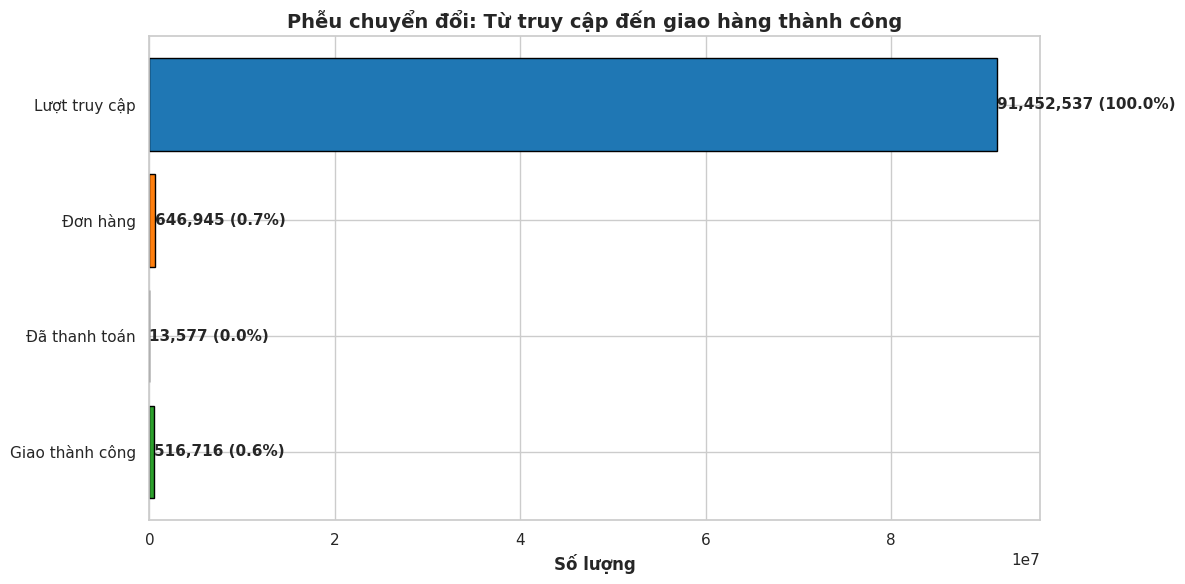

In [ ]:
# ============================================
# BIỂU ĐỒ PHỄU: CHUYỂN ĐỔI TỪ TRAFFIC ĐẾN DOANH THU
# ============================================

# Tính các chỉ số chuyển đổi
total_sessions = data['web_traffic']['sessions'].sum()
total_orders = len(data['orders'])
total_paid_orders = len(data['orders'][data['orders']['order_status'] == 'paid'])
total_delivered = len(data['orders'][data['orders']['order_status'] == 'delivered'])

funnel_data = pd.DataFrame({
    'Giai đoạn': ['Lượt truy cập', 'Đơn hàng', 'Đã thanh toán', 'Giao thành công'],
    'Số lượng': [total_sessions, total_orders, total_paid_orders, total_delivered],
    'Tỷ lệ chuyển đổi': [
        100,
        total_orders / total_sessions * 100,
        total_paid_orders / total_sessions * 100,
        total_delivered / total_sessions * 100
    ]
})

fig, ax = plt.subplots(figsize=(12, 6))
colors = [COLOR_PRIMARY, COLOR_SECONDARY, COLOR_SUCCESS, COLOR_SUCCESS]
bars = ax.barh(funnel_data['Giai đoạn'], funnel_data['Số lượng'], color=colors, edgecolor='black')

for bar, val, pct in zip(bars, funnel_data['Số lượng'], funnel_data['Tỷ lệ chuyển đổi']):
    ax.text(bar.get_width() + 1000, bar.get_y() + bar.get_height()/2,
            f'{val:,} ({pct:.1f}%)', va='center', fontsize=11, fontweight='bold')

ax.set_xlabel('Số lượng', fontsize=12, fontweight='bold')
ax.set_title('Phễu chuyển đổi: Từ truy cập đến giao hàng thành công', fontsize=14, fontweight='bold')
ax.invert_yaxis()
plt.tight_layout()
plt.show()